# SNP System Performance Analysis - Nsys Profiling Results

This notebook analyzes nsys profiling data for different SNP system implementations, **including CPU time extracted from SQLite databases and multi-rank MPI analysis**.

## Implementations Analyzed:
- **CUDA implementations**: optimized-cuda, sparse-cuda
- **MPI+CUDA implementations**: naive/optimized with linear/louvain/red-blue partitioning

## Key Features:
1. **CPU Time Extraction**: Queries nsys SQLite databases to calculate CPU compute time
2. **Multi-Rank Support**: Aggregates data across all MPI ranks and analyzes load balance
3. **Comprehensive Time Breakdown**: CPU, CUDA Kernels, Memory Operations, MPI
4. **Load Balance Analysis**: Per-rank performance comparison and partitioning strategy evaluation
5. **Publication-Ready Visualizations**: High-DPI PDF and PNG outputs
6. **Statistical Tables**: LaTeX-formatted tables for paper inclusion

## Usage:
1. Set the `TIMESTAMP` variable in the configuration cell
2. Run all cells to generate visualizations and tables
3. Outputs are saved to `results/nsys/{TIMESTAMP}/figures/`

## Multi-Rank Analysis:
For MPI implementations, the notebook:
- Detects and processes all available ranks automatically
- Aggregates metrics (sum for work, max for wall time)
- Analyzes load balance across ranks
- Compares partitioning strategies based on load distribution

## CPU Time Calculation:
CPU time is calculated as: **Total Execution Time - (CUDA Kernel Time + CUDA Memory Time + MPI Time)**

This represents the time spent in CPU-side operations including application logic, data preparation, and CUDA API overhead.

In [27]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sqlite3
import warnings
warnings.filterwarnings('ignore')

# Set style for publication-quality plots
plt.style.use('seaborn-v0_8-paper')
sns.set_palette("colorblind")
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 10
plt.rcParams['figure.figsize'] = (8, 5)

In [28]:
# Configuration: Set your timestamp here
TIMESTAMP = "20260104_184616"  # Change this to your profiling run timestamp
BASE_PATH = Path(f"results/nsys/{TIMESTAMP}")

# Define implementations to analyze
CUDA_IMPLS = ["optimized-cuda", "sparse-cuda"]
MPI_IMPLS = [
    "naive-cuda-mpi-linear",
    "naive-cuda-mpi-louvain", 
    "naive-cuda-mpi-red-blue",
    "optimized-cuda-mpi-linear",
    "optimized-cuda-mpi-louvain",
    "optimized-cuda-mpi-red-blue"
]
ALL_IMPLS = CUDA_IMPLS + MPI_IMPLS

# Output directory for figures
OUTPUT_DIR = Path(f"results/nsys/{TIMESTAMP}/figures")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Analysis base path: {BASE_PATH}")
print(f"Output directory: {OUTPUT_DIR}")
print(f"\nChecking available implementations...")
for impl in ALL_IMPLS:
    impl_path = BASE_PATH / impl
    status = "✓" if impl_path.exists() else "✗"
    print(f"{status} {impl}")

Analysis base path: results/nsys/20260104_184616
Output directory: results/nsys/20260104_184616/figures

Checking available implementations...
✓ optimized-cuda
✓ sparse-cuda
✓ naive-cuda-mpi-linear
✓ naive-cuda-mpi-louvain
✓ naive-cuda-mpi-red-blue
✓ optimized-cuda-mpi-linear
✓ optimized-cuda-mpi-louvain
✓ optimized-cuda-mpi-red-blue


## Data Loading Functions

In [29]:
from glob import glob
import re

def get_rank_files(impl, pattern):
    """Get all files matching a pattern for all ranks in an implementation."""
    impl_path = BASE_PATH / impl
    if not impl_path.exists():
        return []
    
    # Match files with rank information
    all_files = list(impl_path.glob(f"*{pattern}"))
    return sorted(all_files)

def extract_rank_number(filename):
    """Extract rank number from filename."""
    match = re.search(r'rank(\d+)', str(filename))
    if match:
        return int(match.group(1))
    return 0

def load_csv_safely(impl, file_suffix, rank=0):
    """
    Load a CSV file for a given implementation.
    If rank is None, loads rank0 file (for backward compatibility).
    If rank is specified, loads that specific rank's file.
    """
    if rank != -1:
        # Load specific rank
        matched_files = glob(str(BASE_PATH / impl / f"*rank{rank}*{file_suffix}"))
    else:
        # Load rank0 by default
        matched_files = glob(str(BASE_PATH / impl / f"*{file_suffix}"))
    
    if not matched_files:
        return None
    elif len(matched_files) > 1:
        print(f"Warning: Multiple files matched for {impl} with suffix {file_suffix} and rank {rank}. Using the first one.")
    
    filepath = Path(matched_files[0])
    if filepath.exists():
        try:
            return pd.read_csv(filepath)
        except Exception as e:
            print(f"Error loading {filepath}: {e}")
    return None

def load_all_ranks_csv(impl, file_suffix):
    """Load CSV files for all ranks of an implementation."""
    rank_files = get_rank_files(impl, file_suffix)
    rank_data = {}
    
    for filepath in rank_files:
        rank = extract_rank_number(filepath)
        try:
            df = pd.read_csv(filepath)
            rank_data[rank] = df
        except Exception as e:
            print(f"Error loading {filepath}: {e}")
    
    return rank_data

def get_num_ranks(impl):
    """Get the number of ranks for an MPI implementation."""
    if impl in CUDA_IMPLS:
        return 1
    
    # Count SQLite files (one per rank)
    sqlite_files = list((BASE_PATH / impl).glob("*.sqlite"))
    return len(sqlite_files)

def load_all_implementations(filename):
    """Load a specific CSV file for all implementations (rank0 only for compatibility)."""
    data = {}
    for impl in ALL_IMPLS:
        df = load_csv_safely(impl, filename)
        if df is not None:
            data[impl] = df
    return data

def get_total_time_ns(impl):
    """Get total execution time for an implementation."""
    # Try to get from CUDA API sum first
    df = load_csv_safely(impl, "stats_cuda_api_sum.csv")
    if df is not None and 'Total Time (ns)' in df.columns:
        return df['Total Time (ns)'].sum()
    return None

print("Data loading functions defined.")

Data loading functions defined.


In [30]:
def get_sqlite_db_path(impl, rank=0):
    """Get the path to the SQLite database for an implementation and rank."""
    if rank != -1:
        db_files = list((BASE_PATH / impl).glob(f"*rank{rank}*.sqlite"))
    else:
        db_files = list((BASE_PATH / impl).glob("*.sqlite"))
    if db_files:
        return db_files[0]
    return None

def get_all_sqlite_db_paths(impl):
    """Get all SQLite database paths for an implementation (all ranks)."""
    db_files = list((BASE_PATH / impl).glob("*.sqlite"))
    rank_dbs = {}
    for db_file in db_files:
        rank = extract_rank_number(db_file)
        rank_dbs[rank] = db_file
    return rank_dbs

def query_nsys_db(impl, query, rank=0):
    """Execute a SQL query on the nsys SQLite database for a specific rank."""
    db_path = get_sqlite_db_path(impl, rank)
    if db_path is None or not db_path.exists():
        print(f"SQLite database not found for {impl} rank {rank}")
        return None
    
    try:
        conn = sqlite3.connect(db_path)
        df = pd.read_sql_query(query, conn)
        conn.close()
        return df
    except Exception as e:
        print(f"Error querying database for {impl} rank {rank}: {e}")
        return None

def get_cpu_time_from_db(impl, rank=0):
    """
    Extract CPU execution time from nsys SQLite database.
    
    This queries the OSRT (OS Runtime) API calls and thread activity to estimate
    CPU time spent outside of CUDA/MPI operations.
    """
    # Query to get thread state information
    query = """
    SELECT 
        SUM(end - start) as total_time_ns
    FROM OSRT_API
    """
    
    df = query_nsys_db(impl, query, rank)
    if df is not None and not df.empty and df['total_time_ns'].iloc[0] is not None:
        return df['total_time_ns'].iloc[0]
    
    # Alternative: Try to get CPU time from thread states
    query_alt = """
    SELECT 
        name,
        SUM(end - start) as time_ns
    FROM CUPTI_ACTIVITY_KIND_RUNTIME
    GROUP BY name
    ORDER BY time_ns DESC
    """
    
    df = query_nsys_db(impl, query_alt, rank)
    if df is not None and not df.empty:
        return df['time_ns'].sum()
    
    return None

def get_execution_timeline(impl, rank=0):
    """
    Get detailed execution timeline showing CPU, GPU, and MPI activity.
    """
    # Get overall timeline bounds
    query = """
    SELECT 
        MIN(start) as min_start,
        MAX(end) as max_end
    FROM (
        SELECT start, end FROM CUPTI_ACTIVITY_KIND_KERNEL
        UNION ALL
        SELECT start, end FROM CUPTI_ACTIVITY_KIND_RUNTIME
        UNION ALL
        SELECT start, end FROM OSRT_API
    )
    """
    
    df = query_nsys_db(impl, query, rank)
    if df is not None and not df.empty:
        total_time = df['max_end'].iloc[0] - df['min_start'].iloc[0]
        return {
            'total_execution_time_ns': total_time,
            'start_ns': df['min_start'].iloc[0],
            'end_ns': df['max_end'].iloc[0]
        }
    return None

def get_detailed_time_breakdown(impl, rank=0):
    """
    Get comprehensive time breakdown including CPU time from SQLite database for a specific rank.
    """
    result = {'implementation': impl, 'rank': rank}
    
    # Get CUDA kernel time from CSV (more reliable)
    gpu_df = load_csv_safely(impl, "stats_cuda_api_gpu_sum.csv", rank=rank)
    if gpu_df is not None:
        cuda_kernel_time = gpu_df[gpu_df['Category'] == 'CUDA_KERNEL']['Total Time (ns)'].sum()
        cuda_mem_time = gpu_df[gpu_df['Category'] == 'MEMORY_OPER']['Total Time (ns)'].sum()
        cuda_api_time = gpu_df[gpu_df['Category'] == 'CUDA_API']['Total Time (ns)'].sum()
        
        result['cuda_kernel_ns'] = cuda_kernel_time
        result['cuda_memory_ns'] = cuda_mem_time
        result['cuda_api_ns'] = cuda_api_time
    else:
        result['cuda_kernel_ns'] = 0
        result['cuda_memory_ns'] = 0
        result['cuda_api_ns'] = 0
    
    # Get MPI time from CSV
    mpi_df = load_csv_safely(impl, "stats_mpi_event_sum.csv", rank=rank)
    if mpi_df is not None:
        result['mpi_ns'] = mpi_df['Total Time (ns)'].sum()
    else:
        result['mpi_ns'] = 0
    
    # Get total execution time from SQLite
    timeline = get_execution_timeline(impl, rank)
    if timeline:
        result['total_execution_ns'] = timeline['total_execution_time_ns']
        
        # Calculate CPU time as: Total - (CUDA kernels + CUDA Memory + MPI)
        gpu_mpi_time = result['cuda_kernel_ns'] + result['cuda_memory_ns'] + result['mpi_ns']
        result['cpu_compute_ns'] = max(0, result['total_execution_ns'] - gpu_mpi_time)
    else:
        # Fallback: use CUDA API time as proxy for CPU time
        result['total_execution_ns'] = sum([
            result['cuda_kernel_ns'],
            result['cuda_memory_ns'],
            result['cuda_api_ns'],
            result['mpi_ns']
        ])
        result['cpu_compute_ns'] = result['cuda_api_ns']
    
    # Convert to seconds for easier reading
    for key in ['cuda_kernel_ns', 'cuda_memory_ns', 'cuda_api_ns', 'mpi_ns', 
                'total_execution_ns', 'cpu_compute_ns']:
        if key in result:
            result[key.replace('_ns', '_s')] = result[key] / 1e9
    
    return result

def get_aggregate_time_breakdown(impl):
    """
    Get aggregated time breakdown across all ranks for an implementation.
    For MPI implementations, this averages metrics across all ranks.
    """
    num_ranks = get_num_ranks(impl)
    
    if num_ranks == 1:
        # CUDA-only implementation
        print(f"Getting time breakdown for CUDA-only implementation: {impl}")
        return get_detailed_time_breakdown(impl, rank=-1)
    
    # MPI implementation - aggregate across all ranks
    rank_breakdowns = []
    for rank in range(num_ranks):
        breakdown = get_detailed_time_breakdown(impl, rank)
        if breakdown:
            rank_breakdowns.append(breakdown)
    
    if not rank_breakdowns:
        return None
    
    # Calculate aggregate metrics (max across ranks for total execution time)
    # and sum for GPU/CPU work
    aggregate = {
        'implementation': impl,
        'num_ranks': num_ranks,
        'cuda_kernel_ns': sum(b['cuda_kernel_ns'] for b in rank_breakdowns),
        'cuda_memory_ns': sum(b['cuda_memory_ns'] for b in rank_breakdowns),
        'cuda_api_ns': sum(b['cuda_api_ns'] for b in rank_breakdowns),
        'mpi_ns': sum(b['mpi_ns'] for b in rank_breakdowns),
        'cpu_compute_ns': sum(b['cpu_compute_ns'] for b in rank_breakdowns),
        'total_execution_ns': max(b['total_execution_ns'] for b in rank_breakdowns),  # Wall time
    }
    
    # Convert to seconds
    for key in ['cuda_kernel_ns', 'cuda_memory_ns', 'cuda_api_ns', 'mpi_ns', 
                'total_execution_ns', 'cpu_compute_ns']:
        aggregate[key.replace('_ns', '_s')] = aggregate[key] / 1e9
    
    return aggregate

print("SQLite query functions defined.")

SQLite query functions defined.


In [31]:
# Test CPU time extraction on one implementation with multiple ranks
test_impl = "optimized-cuda-mpi-linear"
num_ranks = get_num_ranks(test_impl)

print(f"Testing CPU time extraction for: {test_impl}")
print(f"Number of ranks detected: {num_ranks}")
print("="*60)

# Show per-rank breakdown
for rank in range(num_ranks):
    print(f"\n--- Rank {rank} ---")
    breakdown = get_detailed_time_breakdown(test_impl, rank)
    if breakdown:
        total = breakdown.get('total_execution_s', 0)
        print(f"  Total Execution:  {total:.3f} s")
        print(f"  CPU Compute:      {breakdown.get('cpu_compute_s', 0):.3f} s ({breakdown.get('cpu_compute_s', 0) / total * 100:.1f}%)")
        print(f"  CUDA Kernels:     {breakdown.get('cuda_kernel_s', 0):.3f} s ({breakdown.get('cuda_kernel_s', 0) / total * 100:.1f}%)")
        print(f"  CUDA Memory:      {breakdown.get('cuda_memory_s', 0):.3f} s ({breakdown.get('cuda_memory_s', 0) / total * 100:.1f}%)")
        print(f"  MPI:              {breakdown.get('mpi_s', 0):.3f} s ({breakdown.get('mpi_s', 0) / total * 100:.1f}%)")
    else:
        print("  Failed to extract breakdown")

# Show aggregate
print(f"\n--- Aggregate (All Ranks) ---")
aggregate = get_aggregate_time_breakdown(test_impl)
if aggregate:
    print(f"  Wall Time:        {aggregate.get('total_execution_s', 0):.3f} s")
    print(f"  Total CPU:        {aggregate.get('cpu_compute_s', 0):.3f} s")
    print(f"  Total GPU Kernel: {aggregate.get('cuda_kernel_s', 0):.3f} s")
    print(f"  Total MPI:        {aggregate.get('mpi_s', 0):.3f} s")
else:
    print("  Failed to extract aggregate")

# Show available tables in the database for reference
db_path = get_sqlite_db_path(test_impl, rank=0)
if db_path:
    print(f"\n\nAvailable tables in {test_impl} rank0 database:")
    print("="*60)
    try:
        conn = sqlite3.connect(db_path)
        cursor = conn.cursor()
        cursor.execute("SELECT name FROM sqlite_master WHERE type='table' ORDER BY name;")
        tables = cursor.fetchall()
        for table in tables:
            print(f"  - {table[0]}")
        conn.close()
    except Exception as e:
        print(f"Error: {e}")

Testing CPU time extraction for: optimized-cuda-mpi-linear
Number of ranks detected: 3

--- Rank 0 ---
  Total Execution:  0.935 s
  CPU Compute:      0.239 s (25.6%)
  CUDA Kernels:     0.532 s (56.8%)
  CUDA Memory:      0.012 s (1.3%)
  MPI:              0.152 s (16.3%)

--- Rank 1 ---
  Total Execution:  1.139 s
  CPU Compute:      0.184 s (16.2%)
  CUDA Kernels:     0.597 s (52.4%)
  CUDA Memory:      0.010 s (0.9%)
  MPI:              0.347 s (30.5%)

--- Rank 2 ---
  Total Execution:  1.722 s
  CPU Compute:      0.168 s (9.7%)
  CUDA Kernels:     0.021 s (1.2%)
  CUDA Memory:      0.003 s (0.2%)
  MPI:              1.531 s (88.9%)

--- Aggregate (All Ranks) ---
  Wall Time:        1.722 s
  Total CPU:        0.591 s
  Total GPU Kernel: 1.149 s
  Total MPI:        2.031 s


Available tables in optimized-cuda-mpi-linear rank0 database:
  - ANALYSIS_DETAILS
  - ANALYSIS_FILE
  - COMPOSITE_EVENTS
  - CUPTI_ACTIVITY_KIND_KERNEL
  - CUPTI_ACTIVITY_KIND_MEMCPY
  - CUPTI_ACTIVITY_KIND_M

## Test SQLite Database Queries

Verify that we can extract CPU time from the SQLite databases.

## SQLite Database Functions

Extract CPU time and other detailed metrics from nsys SQLite databases.

Analyzing per-rank load balance for MPI implementations...

naive-cuda-mpi-linear: 3 ranks



naive-cuda-mpi-louvain: 3 ranks

naive-cuda-mpi-red-blue: 3 ranks

optimized-cuda-mpi-linear: 3 ranks

optimized-cuda-mpi-louvain: 3 ranks

optimized-cuda-mpi-red-blue: 3 ranks


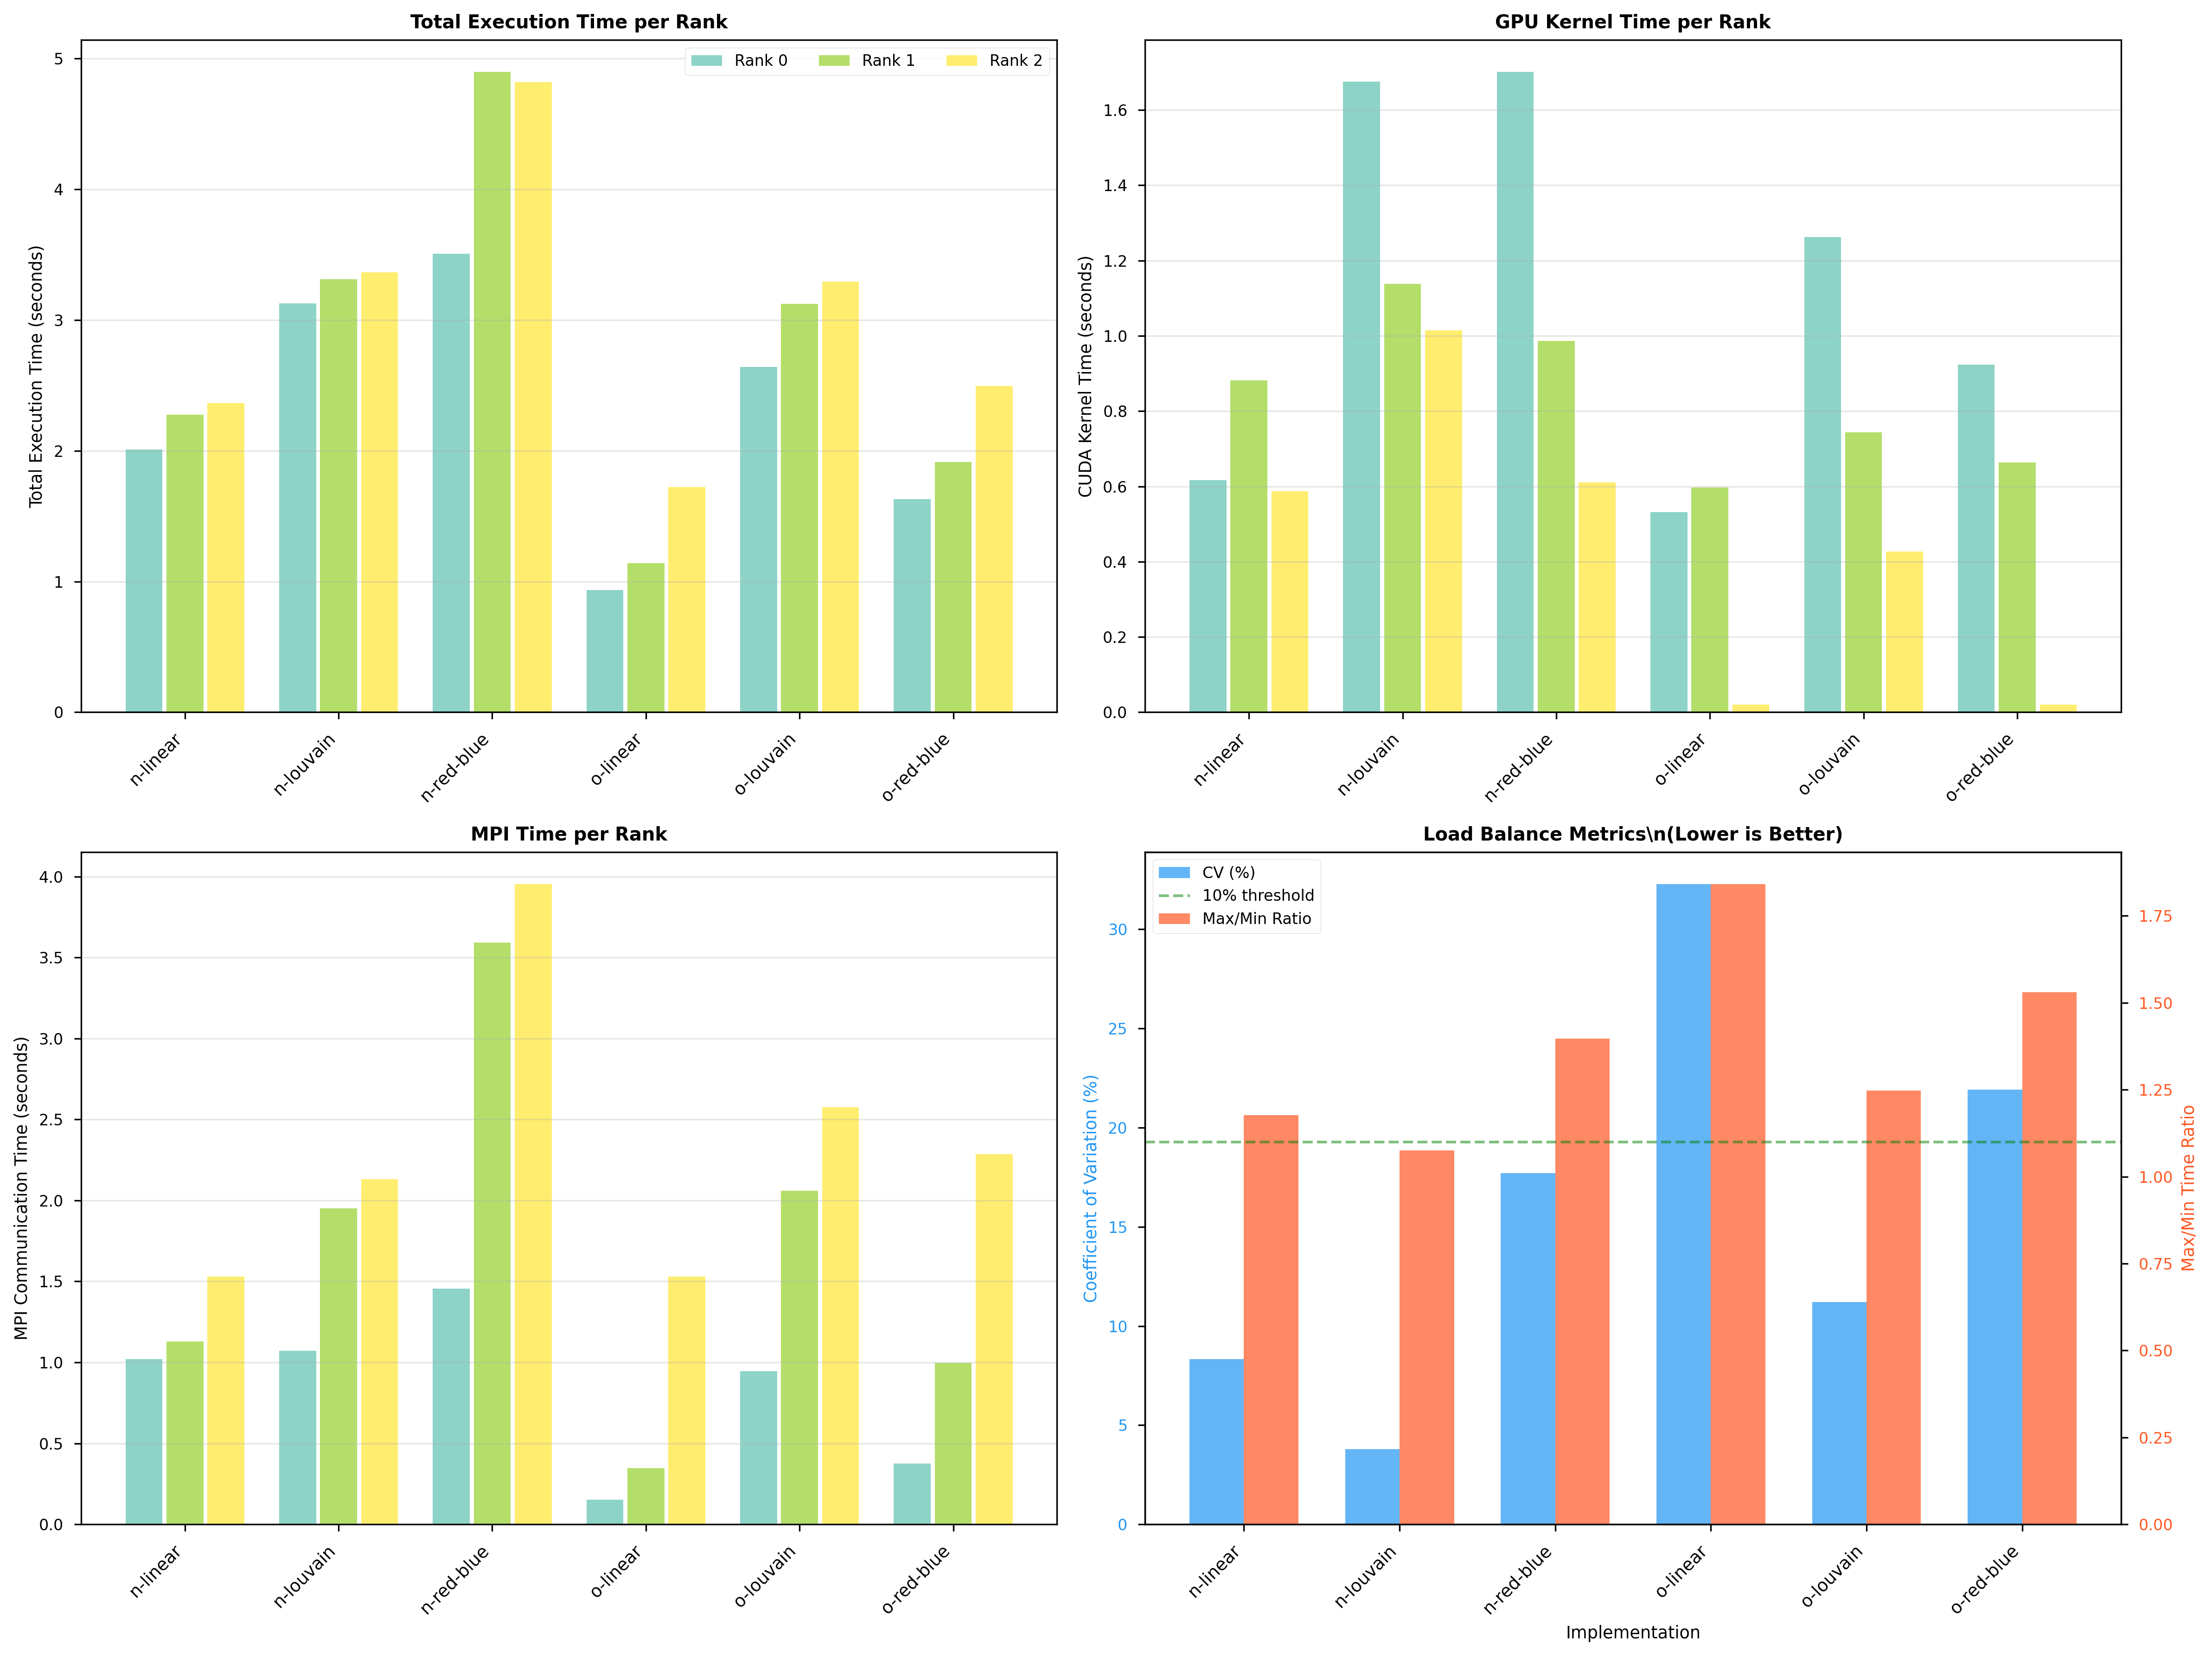


PER-RANK LOAD BALANCE STATISTICS

naive-cuda-mpi-linear:
  Ranks: 3
  Total Time - Mean: 2.215s, Std: 0.184s, Min: 2.008s, Max: 2.363s
  GPU Time   - Mean: 0.695s, Std: 0.162s
  MPI Time   - Mean: 1.226s, Std: 0.269s
  Load Imbalance: 1.18x (max/min ratio)
  Coefficient of Variation: 8.3%

naive-cuda-mpi-louvain:
  Ranks: 3
  Total Time - Mean: 3.267s, Std: 0.124s, Min: 3.127s, Max: 3.363s
  GPU Time   - Mean: 1.276s, Std: 0.351s
  MPI Time   - Mean: 1.718s, Std: 0.566s
  Load Imbalance: 1.08x (max/min ratio)
  Coefficient of Variation: 3.8%

naive-cuda-mpi-red-blue:
  Ranks: 3
  Total Time - Mean: 4.407s, Std: 0.780s, Min: 3.507s, Max: 4.896s
  GPU Time   - Mean: 1.100s, Std: 0.554s
  MPI Time   - Mean: 3.000s, Std: 1.350s
  Load Imbalance: 1.40x (max/min ratio)
  Coefficient of Variation: 17.7%

optimized-cuda-mpi-linear:
  Ranks: 3
  Total Time - Mean: 1.265s, Std: 0.409s, Min: 0.935s, Max: 1.722s
  GPU Time   - Mean: 0.383s, Std: 0.316s
  MPI Time   - Mean: 0.677s, Std: 0.746s
  L

In [32]:
# Analyze per-rank performance for MPI implementations
print("Analyzing per-rank load balance for MPI implementations...")

rank_analysis = []
for impl in MPI_IMPLS:
    num_ranks = get_num_ranks(impl)
    if num_ranks <= 1:
        print(f"Skipping {impl}: only 1 rank found")
        continue
    
    print(f"\n{impl}: {num_ranks} ranks")
    for rank in range(num_ranks):
        breakdown = get_detailed_time_breakdown(impl, rank)
        if breakdown:
            rank_analysis.append({
                'implementation': impl,
                'rank': rank,
                'cpu_compute_s': breakdown.get('cpu_compute_s', 0),
                'cuda_kernel_s': breakdown.get('cuda_kernel_s', 0),
                'cuda_memory_s': breakdown.get('cuda_memory_s', 0),
                'mpi_s': breakdown.get('mpi_s', 0),
                'total_s': breakdown.get('total_execution_s', 0)
            })

rank_df = pd.DataFrame(rank_analysis)

if not rank_df.empty:
    # Create visualization with vertical grouped bars
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Prepare data for grouped vertical bars
    implementations = rank_df['implementation'].unique()
    max_ranks = rank_df['rank'].max() + 1
    
    # Define colors for ranks (use a colormap)
    rank_colors = plt.cm.Set3(np.linspace(0, 1, max_ranks))
    
    # Calculate bar positions
    n_impls = len(implementations)
    bar_width = 0.8 / max_ranks  # Width of each sub-bar
    
    # Plot 1: Total execution time per rank (grouped vertical bars)
    ax = axes[0, 0]
    for rank in range(max_ranks):
        positions = []
        heights = []
        for impl_idx, impl in enumerate(implementations):
            impl_data = rank_df[(rank_df['implementation'] == impl) & (rank_df['rank'] == rank)]
            if not impl_data.empty:
                positions.append(impl_idx + rank * bar_width - 0.4 + bar_width/2)
                heights.append(impl_data['total_s'].values[0])
            else:
                positions.append(impl_idx + rank * bar_width - 0.4 + bar_width/2)
                heights.append(0)
        ax.bar(positions, heights, width=bar_width * 0.9, 
               color=rank_colors[rank], label=f'Rank {rank}')
    
    ax.set_xticks(range(n_impls))
    ax.set_xticklabels([impl.replace('naive-cuda-mpi-', 'n-').replace('optimized-cuda-mpi-', 'o-') 
                        for impl in implementations], rotation=45, ha='right', fontsize=9)
    ax.set_ylabel('Total Execution Time (seconds)')
    ax.set_title('Total Execution Time per Rank', fontweight='bold')
    ax.legend(loc='best', fontsize=8, ncol=max_ranks)
    ax.grid(axis='y', alpha=0.3)
    
    # Plot 2: GPU kernel time per rank (grouped vertical bars)
    ax = axes[0, 1]
    for rank in range(max_ranks):
        positions = []
        heights = []
        for impl_idx, impl in enumerate(implementations):
            impl_data = rank_df[(rank_df['implementation'] == impl) & (rank_df['rank'] == rank)]
            if not impl_data.empty:
                positions.append(impl_idx + rank * bar_width - 0.4 + bar_width/2)
                heights.append(impl_data['cuda_kernel_s'].values[0])
            else:
                positions.append(impl_idx + rank * bar_width - 0.4 + bar_width/2)
                heights.append(0)
        ax.bar(positions, heights, width=bar_width * 0.9, color=rank_colors[rank])
    
    ax.set_xticks(range(n_impls))
    ax.set_xticklabels([impl.replace('naive-cuda-mpi-', 'n-').replace('optimized-cuda-mpi-', 'o-') 
                        for impl in implementations], rotation=45, ha='right', fontsize=9)
    ax.set_ylabel('CUDA Kernel Time (seconds)')
    ax.set_title('GPU Kernel Time per Rank', fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    
    # Plot 3: MPI communication time per rank (grouped vertical bars)
    ax = axes[1, 0]
    for rank in range(max_ranks):
        positions = []
        heights = []
        for impl_idx, impl in enumerate(implementations):
            impl_data = rank_df[(rank_df['implementation'] == impl) & (rank_df['rank'] == rank)]
            if not impl_data.empty:
                positions.append(impl_idx + rank * bar_width - 0.4 + bar_width/2)
                heights.append(impl_data['mpi_s'].values[0])
            else:
                positions.append(impl_idx + rank * bar_width - 0.4 + bar_width/2)
                heights.append(0)
        ax.bar(positions, heights, width=bar_width * 0.9, color=rank_colors[rank])
    
    ax.set_xticks(range(n_impls))
    ax.set_xticklabels([impl.replace('naive-cuda-mpi-', 'n-').replace('optimized-cuda-mpi-', 'o-') 
                        for impl in implementations], rotation=45, ha='right', fontsize=9)
    ax.set_ylabel('MPI Communication Time (seconds)')
    ax.set_title('MPI Time per Rank', fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    
    # Plot 4: Load balance metrics (coefficient of variation)
    ax = axes[1, 1]
    load_balance = []
    for impl in implementations:
        impl_data = rank_df[rank_df['implementation'] == impl]
        mean_time = impl_data['total_s'].mean()
        std_time = impl_data['total_s'].std()
        cv = (std_time / mean_time * 100) if mean_time > 0 else 0  # Coefficient of variation
        load_balance.append({
            'implementation': impl.replace('naive-cuda-mpi-', 'n-').replace('optimized-cuda-mpi-', 'o-'),
            'cv': cv,
            'imbalance': impl_data['total_s'].max() / impl_data['total_s'].min() if impl_data['total_s'].min() > 0 else 1
        })
    
    lb_df = pd.DataFrame(load_balance)
    x = range(len(lb_df))
    width = 0.35
    
    ax2 = ax.twinx()
    bars1 = ax.bar([i - width/2 for i in x], lb_df['cv'], width, 
                   label='CV (%)', color='#2196F3', alpha=0.7)
    bars2 = ax2.bar([i + width/2 for i in x], lb_df['imbalance'], width,
                    label='Max/Min Ratio', color='#FF5722', alpha=0.7)
    
    ax.set_xlabel('Implementation')
    ax.set_ylabel('Coefficient of Variation (%)', color='#2196F3')
    ax.tick_params(axis='y', labelcolor='#2196F3')
    ax.set_xticks(x)
    ax.set_xticklabels(lb_df['implementation'], rotation=45, ha='right', fontsize=9)
    ax.set_title('Load Balance Metrics\\n(Lower is Better)', fontweight='bold')
    
    ax2.set_ylabel('Max/Min Time Ratio', color='#FF5722')
    ax2.tick_params(axis='y', labelcolor='#FF5722')
    ax2.axhline(y=1.1, color='green', linestyle='--', alpha=0.5, label='10% threshold')
    
    # Combine legends
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=8)
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'per_rank_load_balance.pdf', bbox_inches='tight')
    plt.savefig(OUTPUT_DIR / 'per_rank_load_balance.png', bbox_inches='tight')
    plt.show()
    
    # Print detailed statistics
    print("\n" + "="*80)
    print("PER-RANK LOAD BALANCE STATISTICS")
    print("="*80)
    for impl in rank_df['implementation'].unique():
        impl_data = rank_df[rank_df['implementation'] == impl]
        print(f"\n{impl}:")
        print(f"  Ranks: {len(impl_data)}")
        print(f"  Total Time - Mean: {impl_data['total_s'].mean():.3f}s, "
              f"Std: {impl_data['total_s'].std():.3f}s, "
              f"Min: {impl_data['total_s'].min():.3f}s, "
              f"Max: {impl_data['total_s'].max():.3f}s")
        print(f"  GPU Time   - Mean: {impl_data['cuda_kernel_s'].mean():.3f}s, "
              f"Std: {impl_data['cuda_kernel_s'].std():.3f}s")
        print(f"  MPI Time   - Mean: {impl_data['mpi_s'].mean():.3f}s, "
              f"Std: {impl_data['mpi_s'].std():.3f}s")
        imbalance = impl_data['total_s'].max() / impl_data['total_s'].min() if impl_data['total_s'].min() > 0 else 1
        cv = (impl_data['total_s'].std() / impl_data['total_s'].mean() * 100) if impl_data['total_s'].mean() > 0 else 0
        print(f"  Load Imbalance: {imbalance:.2f}x (max/min ratio)")
        print(f"  Coefficient of Variation: {cv:.1f}%")
    print("="*80)
else:
    print("No per-rank data available for analysis.")

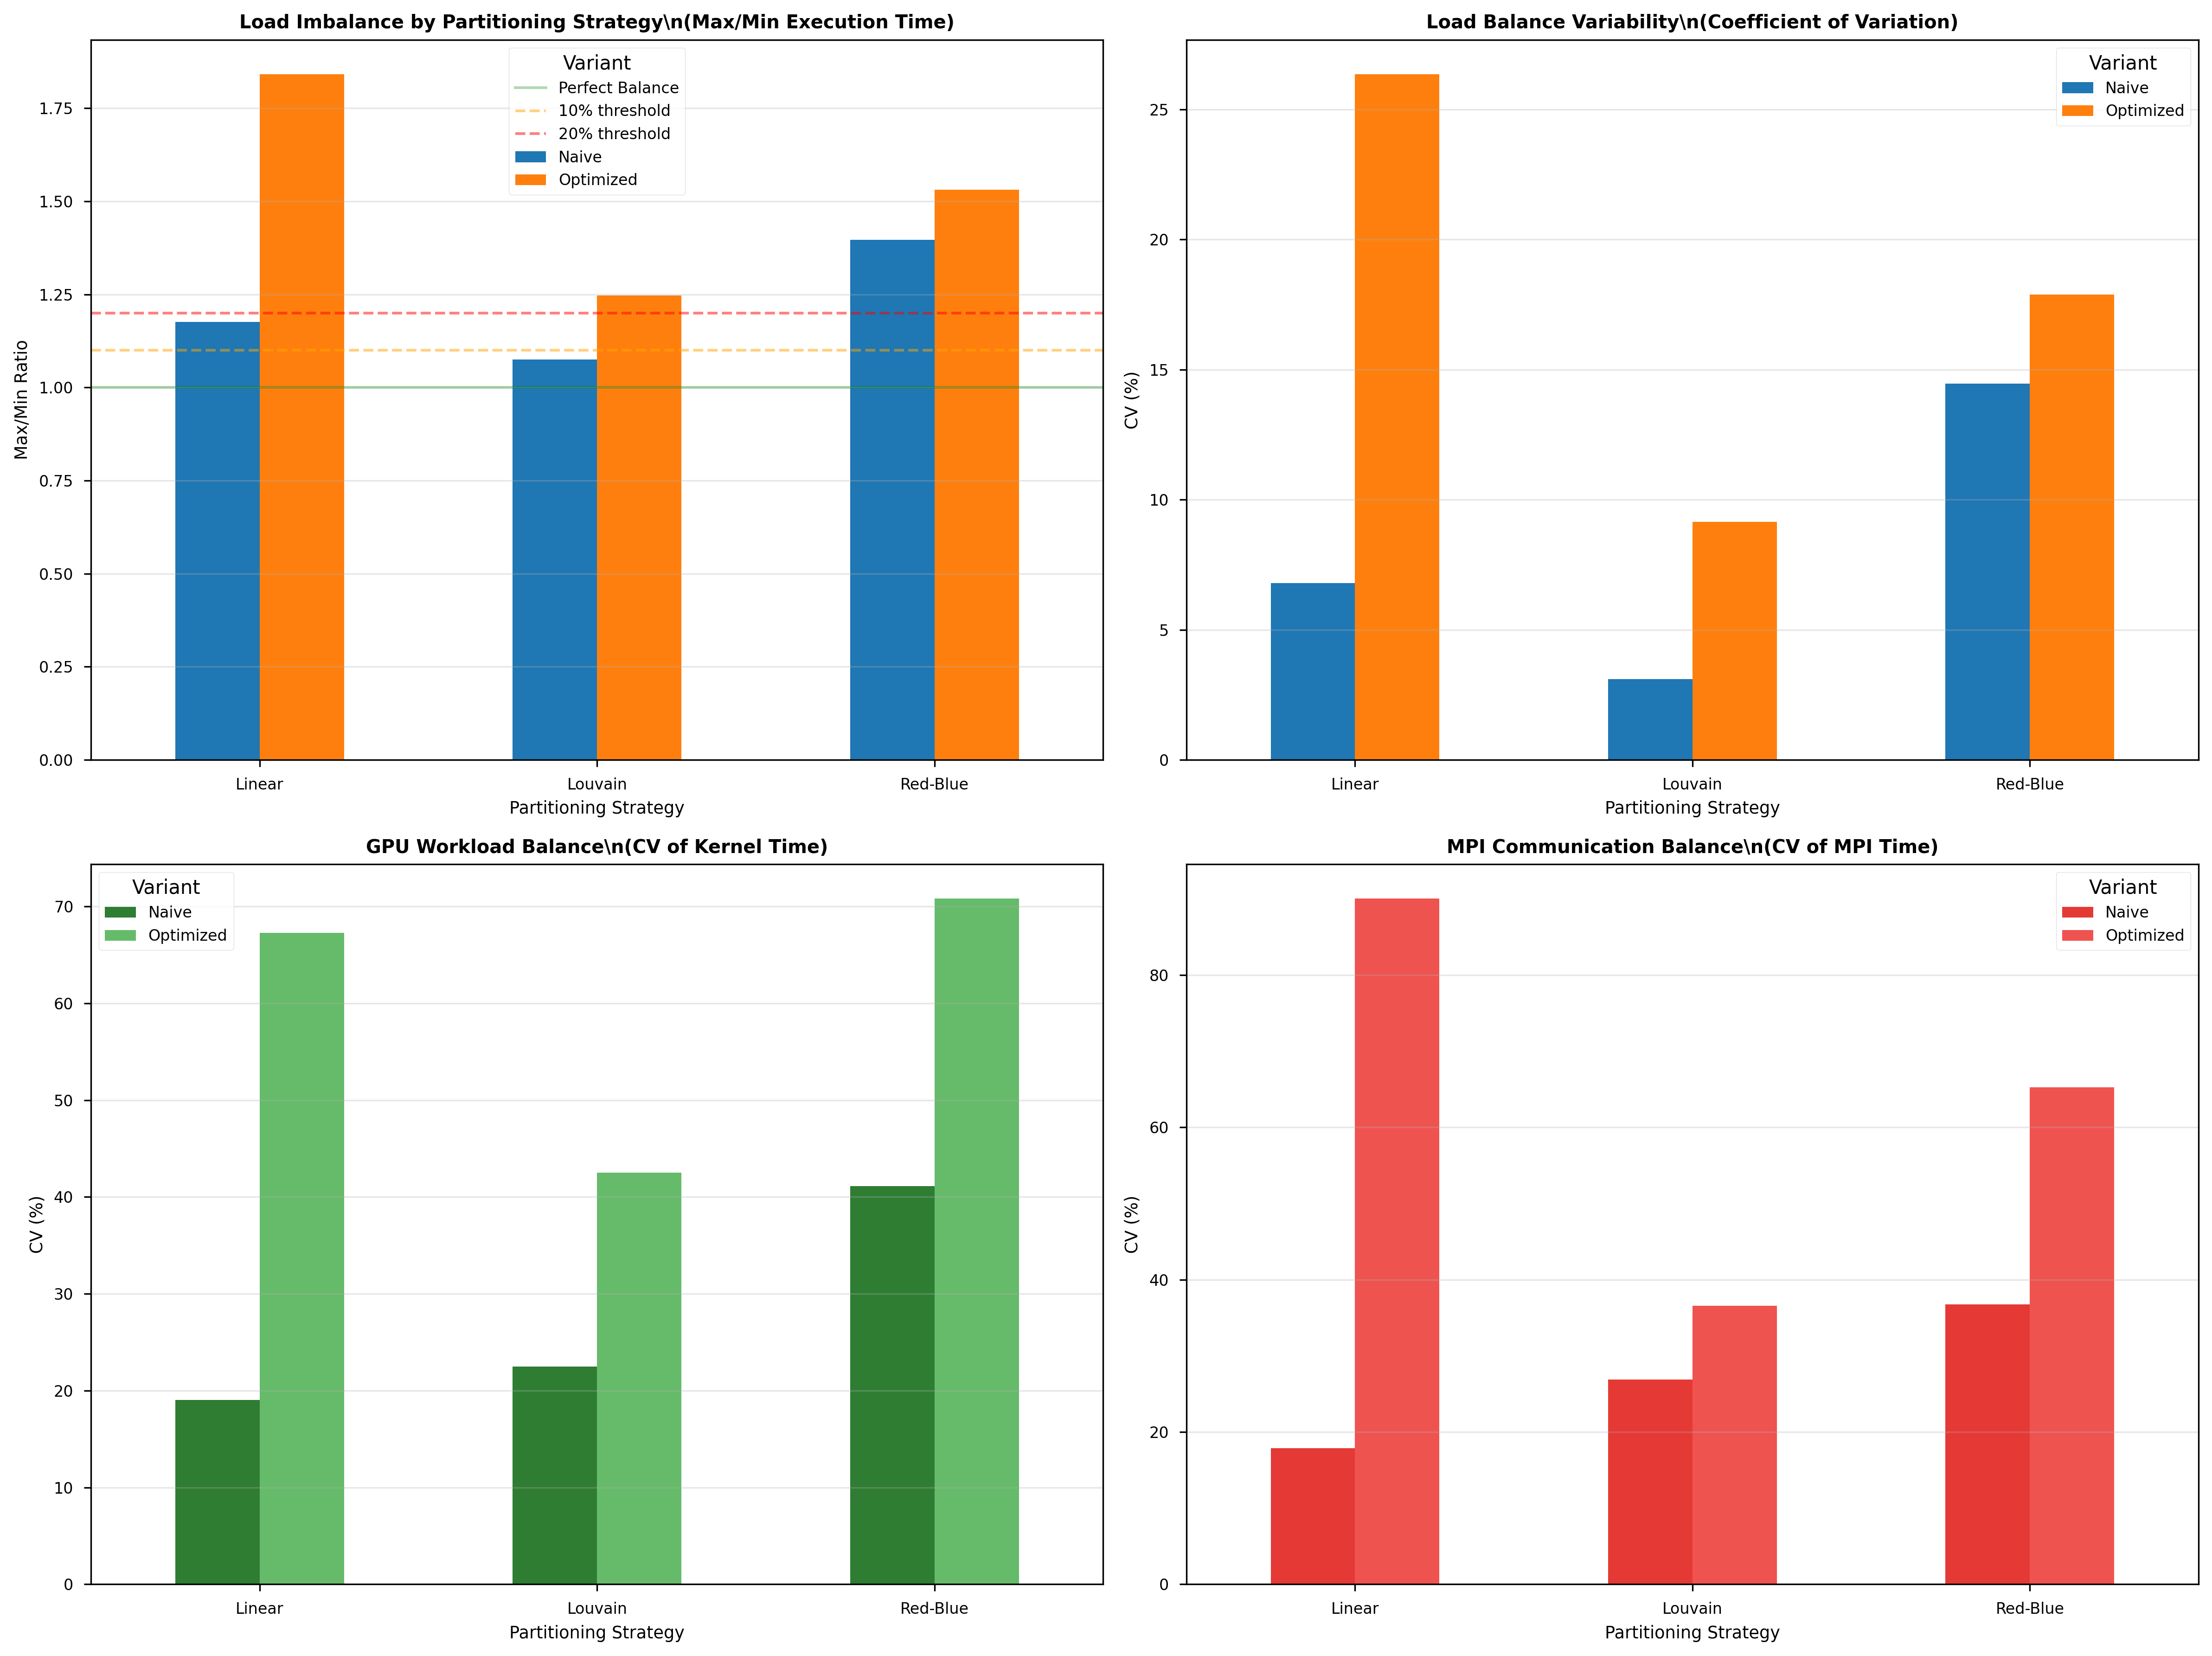


PARTITIONING STRATEGY LOAD BALANCE COMPARISON

Load Imbalance (Max/Min Ratio) - Lower is Better:
variant      Naive  Optimized
strategy                     
Linear    1.176296   1.841490
Louvain   1.075583   1.247275
Red-Blue  1.396216   1.530584

Load Variability (CV %) - Lower is Better:
variant       Naive  Optimized
strategy                      
Linear     6.796658  26.359290
Louvain    3.105200   9.155892
Red-Blue  14.459156  17.886947

GPU Workload Balance (CV %):
variant       Naive  Optimized
strategy                      
Linear    19.053519  67.267812
Louvain   22.463807  42.489260
Red-Blue  41.123969  70.803431

MPI Communication Balance (CV %):
variant       Naive  Optimized
strategy                      
Linear    17.899143  90.009583
Louvain   26.910563  36.583419
Red-Blue  36.739915  65.260151

✓ Best Load Balance: Louvain (Naive)
  Imbalance: 1.076x, CV: 3.1%


In [33]:
# Compare partitioning strategies with per-rank data
def extract_strategy(impl_name):
    """Extract partitioning strategy from implementation name."""
    if 'linear' in impl_name:
        return 'Linear'
    elif 'louvain' in impl_name:
        return 'Louvain'
    elif 'red-blue' in impl_name:
        return 'Red-Blue'
    return None

def extract_variant(impl_name):
    """Extract naive vs optimized variant."""
    return 'Naive' if 'naive' in impl_name else 'Optimized'

if not rank_df.empty:
    # Calculate load balance metrics by strategy
    strategy_balance = []
    
    for impl in rank_df['implementation'].unique():
        impl_data = rank_df[rank_df['implementation'] == impl]
        strategy = extract_strategy(impl)
        variant = extract_variant(impl)
        
        if len(impl_data) > 1:
            total_times = impl_data['total_s'].values
            gpu_times = impl_data['cuda_kernel_s'].values
            mpi_times = impl_data['mpi_s'].values
            
            strategy_balance.append({
                'strategy': strategy,
                'variant': variant,
                'impl': impl,
                'num_ranks': len(impl_data),
                # Total time metrics
                'total_mean': total_times.mean(),
                'total_std': total_times.std(),
                'total_cv': (total_times.std() / total_times.mean() * 100) if total_times.mean() > 0 else 0,
                'total_imbalance': total_times.max() / total_times.min() if total_times.min() > 0 else 1,
                # GPU time metrics
                'gpu_mean': gpu_times.mean(),
                'gpu_std': gpu_times.std(),
                'gpu_cv': (gpu_times.std() / gpu_times.mean() * 100) if gpu_times.mean() > 0 else 0,
                # MPI time metrics
                'mpi_mean': mpi_times.mean(),
                'mpi_std': mpi_times.std(),
                'mpi_cv': (mpi_times.std() / mpi_times.mean() * 100) if mpi_times.mean() > 0 else 0,
            })
    
    balance_df = pd.DataFrame(strategy_balance)
    
    if not balance_df.empty:
        fig, axes = plt.subplots(2, 2, figsize=(16, 12))
        
        # Plot 1: Load imbalance by strategy
        ax = axes[0, 0]
        pivot_imbalance = balance_df.pivot(index='strategy', columns='variant', values='total_imbalance')
        pivot_imbalance.plot(kind='bar', ax=ax, color=['#1f77b4', '#ff7f0e'])
        ax.set_title('Load Imbalance by Partitioning Strategy\\n(Max/Min Execution Time)', fontweight='bold')
        ax.set_ylabel('Max/Min Ratio')
        ax.set_xlabel('Partitioning Strategy')
        ax.axhline(y=1.0, color='green', linestyle='-', alpha=0.3, label='Perfect Balance')
        ax.axhline(y=1.1, color='orange', linestyle='--', alpha=0.5, label='10% threshold')
        ax.axhline(y=1.2, color='red', linestyle='--', alpha=0.5, label='20% threshold')
        ax.legend(title='Variant')
        ax.tick_params(axis='x', rotation=0)
        ax.grid(axis='y', alpha=0.3)
        
        # Plot 2: Coefficient of variation
        ax = axes[0, 1]
        pivot_cv = balance_df.pivot(index='strategy', columns='variant', values='total_cv')
        pivot_cv.plot(kind='bar', ax=ax, color=['#1f77b4', '#ff7f0e'])
        ax.set_title('Load Balance Variability\\n(Coefficient of Variation)', fontweight='bold')
        ax.set_ylabel('CV (%)')
        ax.set_xlabel('Partitioning Strategy')
        ax.legend(title='Variant')
        ax.tick_params(axis='x', rotation=0)
        ax.grid(axis='y', alpha=0.3)
        
        # Plot 3: GPU time distribution
        ax = axes[1, 0]
        pivot_gpu = balance_df.pivot(index='strategy', columns='variant', values='gpu_cv')
        pivot_gpu.plot(kind='bar', ax=ax, color=['#2E7D32', '#66BB6A'])
        ax.set_title('GPU Workload Balance\\n(CV of Kernel Time)', fontweight='bold')
        ax.set_ylabel('CV (%)')
        ax.set_xlabel('Partitioning Strategy')
        ax.legend(title='Variant')
        ax.tick_params(axis='x', rotation=0)
        ax.grid(axis='y', alpha=0.3)
        
        # Plot 4: MPI time distribution
        ax = axes[1, 1]
        pivot_mpi = balance_df.pivot(index='strategy', columns='variant', values='mpi_cv')
        pivot_mpi.plot(kind='bar', ax=ax, color=['#E53935', '#EF5350'])
        ax.set_title('MPI Communication Balance\\n(CV of MPI Time)', fontweight='bold')
        ax.set_ylabel('CV (%)')
        ax.set_xlabel('Partitioning Strategy')
        ax.legend(title='Variant')
        ax.tick_params(axis='x', rotation=0)
        ax.grid(axis='y', alpha=0.3)
        
        plt.tight_layout()
        plt.savefig(OUTPUT_DIR / 'partitioning_load_balance.pdf', bbox_inches='tight')
        plt.savefig(OUTPUT_DIR / 'partitioning_load_balance.png', bbox_inches='tight')
        plt.show()
        
        # Print summary table
        print("\n" + "="*100)
        print("PARTITIONING STRATEGY LOAD BALANCE COMPARISON")
        print("="*100)
        print("\nLoad Imbalance (Max/Min Ratio) - Lower is Better:")
        print(pivot_imbalance.to_string())
        print("\nLoad Variability (CV %) - Lower is Better:")
        print(pivot_cv.to_string())
        print("\nGPU Workload Balance (CV %):")
        print(pivot_gpu.to_string())
        print("\nMPI Communication Balance (CV %):")
        print(pivot_mpi.to_string())
        print("="*100)
        
        # Identify best partitioning strategy
        best_strategy = balance_df.loc[balance_df['total_imbalance'].idxmin()]
        print(f"\n✓ Best Load Balance: {best_strategy['strategy']} ({best_strategy['variant']})")
        print(f"  Imbalance: {best_strategy['total_imbalance']:.3f}x, CV: {best_strategy['total_cv']:.1f}%")
    else:
        print("Insufficient data for partitioning strategy comparison")
else:
    print("No per-rank data available for partitioning strategy comparison")

## Visualization 4: Partitioning Strategy Impact on Load Balance

**Purpose**: Compare how different partitioning strategies affect load distribution across ranks.

## Visualization 3: Per-Rank Load Balance Analysis

**Purpose**: Shows load distribution across MPI ranks to identify load imbalance and bottlenecks.

## Visualization 2: CPU vs GPU Time Comparison

**Purpose**: Highlights the effectiveness of GPU offloading by comparing CPU and GPU execution time.

Extracting time breakdown with CPU data from SQLite databases...
For MPI implementations, aggregating across all ranks...

Getting time breakdown for CUDA-only implementation: optimized-cuda
Error loading results/nsys/20260104_184616/optimized-cuda/snp_profile_stats_mpi_event_sum.csv: No columns to parse from file
optimized-cuda: 1 rank(s)
Getting time breakdown for CUDA-only implementation: sparse-cuda
Error loading results/nsys/20260104_184616/sparse-cuda/snp_profile_stats_mpi_event_sum.csv: No columns to parse from file
sparse-cuda: 1 rank(s)


naive-cuda-mpi-linear: 3 rank(s)
naive-cuda-mpi-louvain: 3 rank(s)
naive-cuda-mpi-red-blue: 3 rank(s)
optimized-cuda-mpi-linear: 3 rank(s)
optimized-cuda-mpi-louvain: 3 rank(s)
optimized-cuda-mpi-red-blue: 3 rank(s)


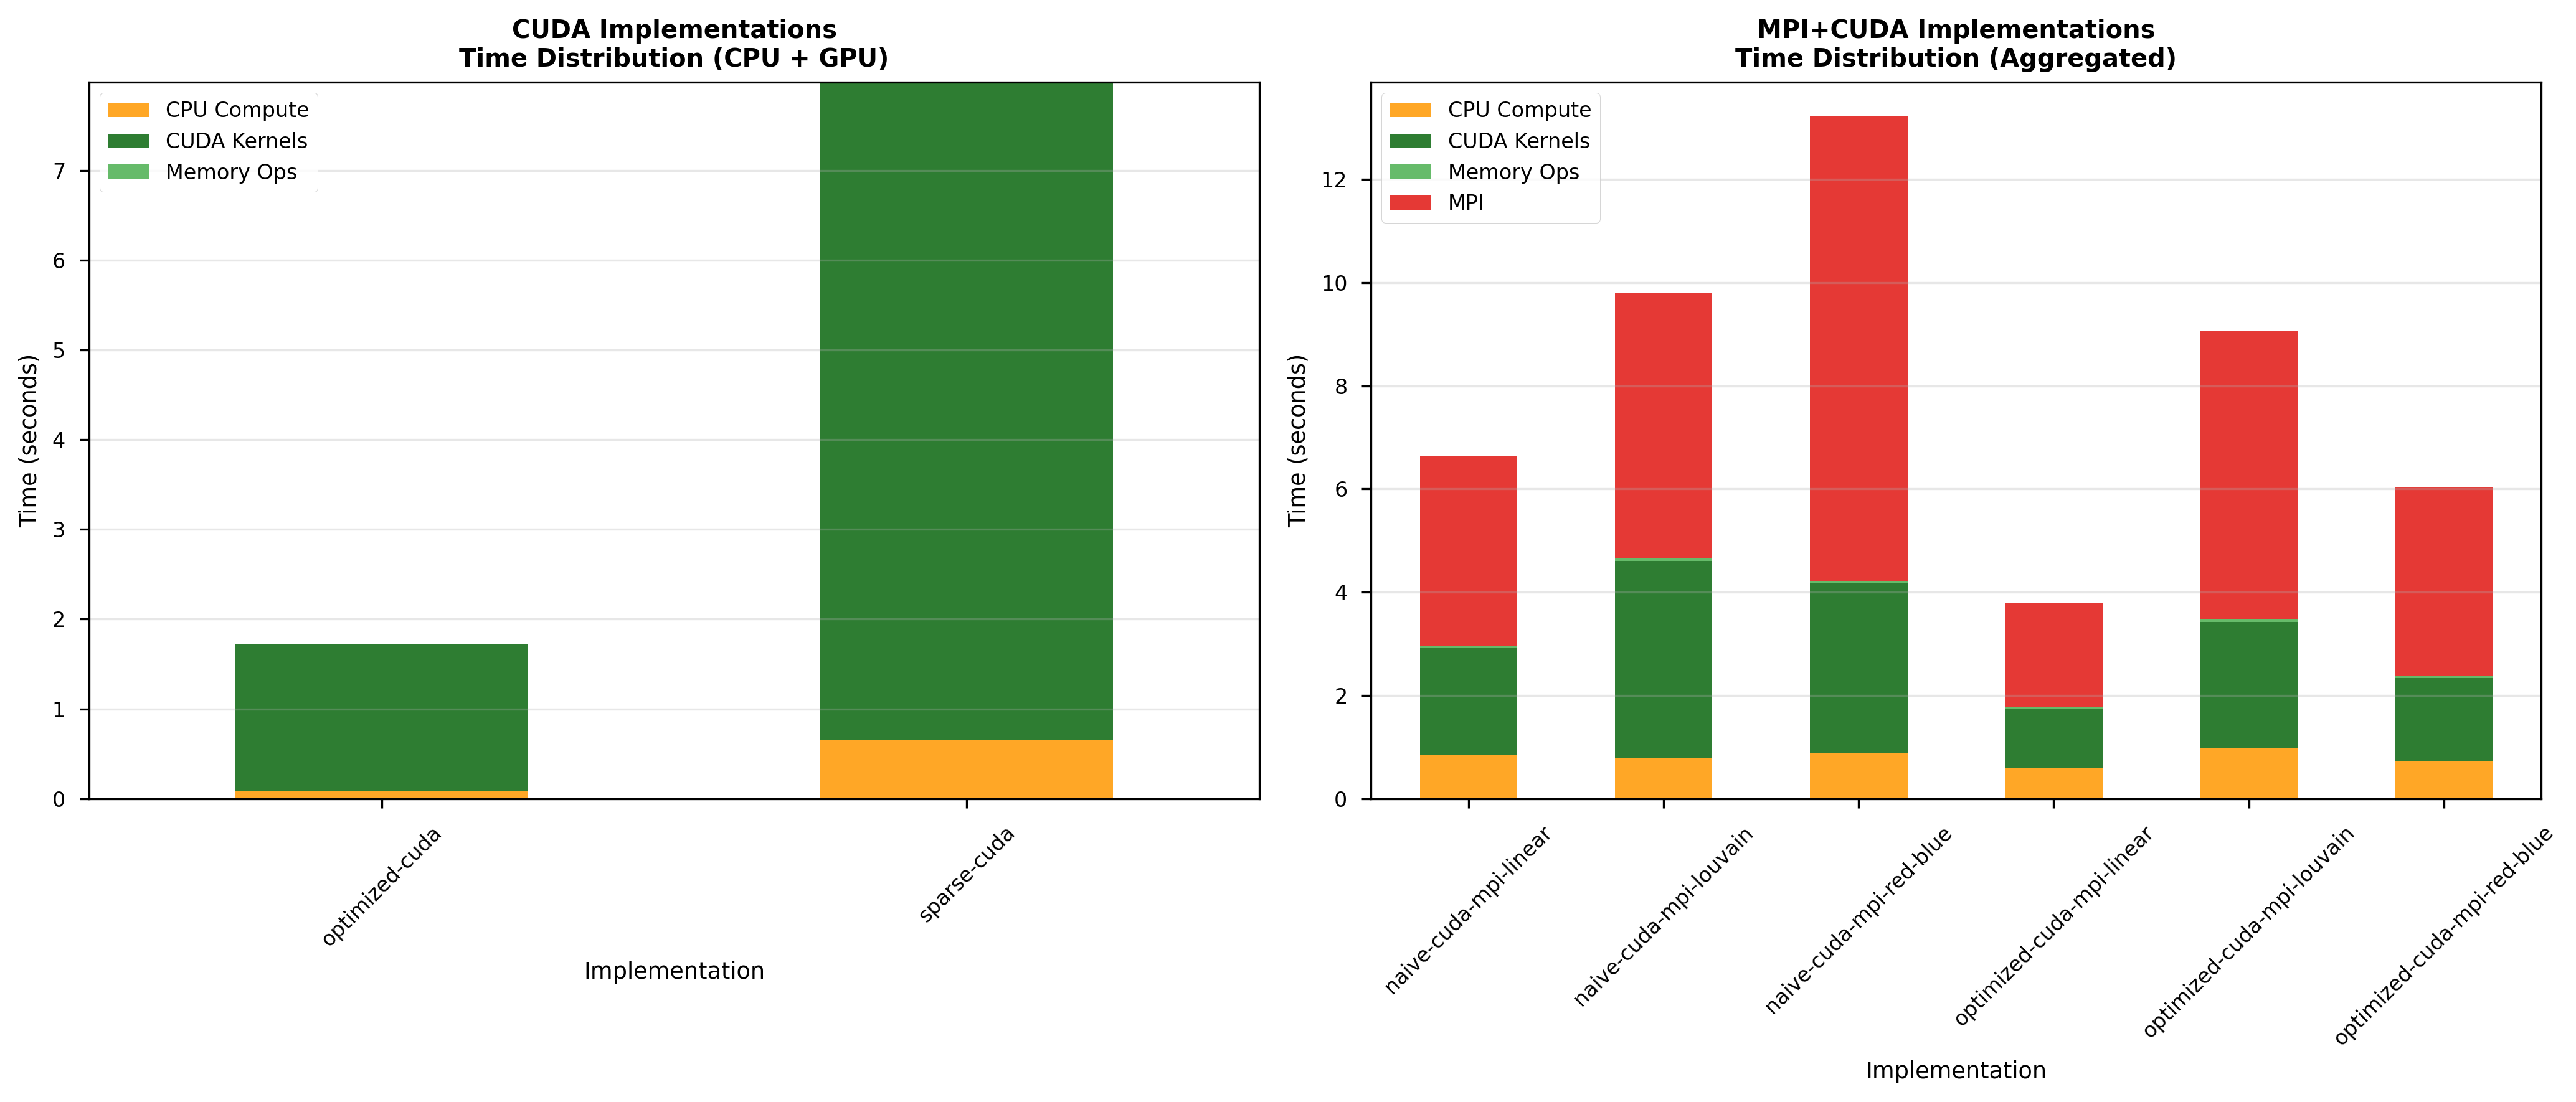


Time Distribution Summary with CPU (seconds):
             implementation  cpu_compute  cuda_kernel  cuda_memory      mpi    total  num_ranks
             optimized-cuda     0.082819     1.637285     0.000004 0.000000 1.720108          1
                sparse-cuda     0.649412     7.332431     0.000004 0.000000 7.981848          1
      naive-cuda-mpi-linear     0.847515     2.085164     0.036520 3.676739 2.362574          3
     naive-cuda-mpi-louvain     0.781766     3.827710     0.038856 5.152569 3.362952          3
    naive-cuda-mpi-red-blue     0.882067     3.298539     0.038339 9.000627 4.896000          3
  optimized-cuda-mpi-linear     0.591330     1.149046     0.025194 2.030521 1.722204          3
 optimized-cuda-mpi-louvain     0.988500     2.432161     0.055651 5.580976 3.293969          3
optimized-cuda-mpi-red-blue     0.733255     1.608059     0.036895 3.659693 2.494773          3


Percentage Breakdown:

optimized-cuda (1 rank(s)):
  CPU Compute:    4.8%
  CUDA Kernel

In [34]:
# Calculate time breakdown for all implementations (using aggregated multi-rank data)
print("Extracting time breakdown with CPU data from SQLite databases...")
print("For MPI implementations, aggregating across all ranks...\n")

time_breakdown = []
for impl in ALL_IMPLS:
    breakdown = get_aggregate_time_breakdown(impl)
    if breakdown:
        num_ranks = breakdown.get('num_ranks', 1)
        print(f"{impl}: {num_ranks} rank(s)")
        
        time_breakdown.append({
            'implementation': impl,
            'cpu_compute': breakdown.get('cpu_compute_s', 0),
            'cuda_kernel': breakdown.get('cuda_kernel_s', 0),
            'cuda_memory': breakdown.get('cuda_memory_s', 0),
            'mpi': breakdown.get('mpi_s', 0),
            'total': breakdown.get('total_execution_s', 0),
            'num_ranks': num_ranks
        })

time_df = pd.DataFrame(time_breakdown)

# Create figure with subplots for CUDA and MPI implementations
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: CUDA-only implementations
cuda_data = time_df[time_df['implementation'].isin(CUDA_IMPLS)]
if not cuda_data.empty:
    ax = axes[0]
    cuda_plot_data = cuda_data.set_index('implementation')[['cpu_compute', 'cuda_kernel', 'cuda_memory']]
    cuda_plot_data.plot(kind='bar', stacked=True, ax=ax, 
                        color=['#FFA726', '#2E7D32', '#66BB6A'])
    ax.set_title('CUDA Implementations\nTime Distribution (CPU + GPU)', fontweight='bold')
    ax.set_xlabel('Implementation')
    ax.set_ylabel('Time (seconds)')
    ax.legend(['CPU Compute', 'CUDA Kernels', 'Memory Ops'], loc='upper left')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='y', alpha=0.3)

# Plot 2: MPI+CUDA implementations
mpi_data = time_df[time_df['implementation'].isin(MPI_IMPLS)]
if not mpi_data.empty:
    ax = axes[1]
    mpi_plot_data = mpi_data.set_index('implementation')[['cpu_compute', 'cuda_kernel', 'cuda_memory', 'mpi']]
    mpi_plot_data.plot(kind='bar', stacked=True, ax=ax,
                       color=['#FFA726', '#2E7D32', '#66BB6A', '#E53935'])
    ax.set_title('MPI+CUDA Implementations\nTime Distribution (Aggregated)', fontweight='bold')
    ax.set_xlabel('Implementation')
    ax.set_ylabel('Time (seconds)')
    ax.legend(['CPU Compute', 'CUDA Kernels', 'Memory Ops', 'MPI'], loc='upper left')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'time_distribution_with_cpu.pdf', bbox_inches='tight')
plt.savefig(OUTPUT_DIR / 'time_distribution_with_cpu.png', bbox_inches='tight')
plt.show()

print("\nTime Distribution Summary with CPU (seconds):")
print(time_df.to_string(index=False))

# Show percentage breakdown
print("\n\nPercentage Breakdown:")
for _, row in time_df.iterrows():
    total = row['total']
    if total > 0:
        print(f"\n{row['implementation']} ({row['num_ranks']} rank(s)):")
        print(f"  CPU Compute:  {row['cpu_compute']/total*100:5.1f}%")
        print(f"  CUDA Kernels: {row['cuda_kernel']/total*100:5.1f}%")
        print(f"  CUDA Memory:  {row['cuda_memory']/total*100:5.1f}%")
        if row['mpi'] > 0:
            print(f"  MPI:          {row['mpi']/total*100:5.1f}%")

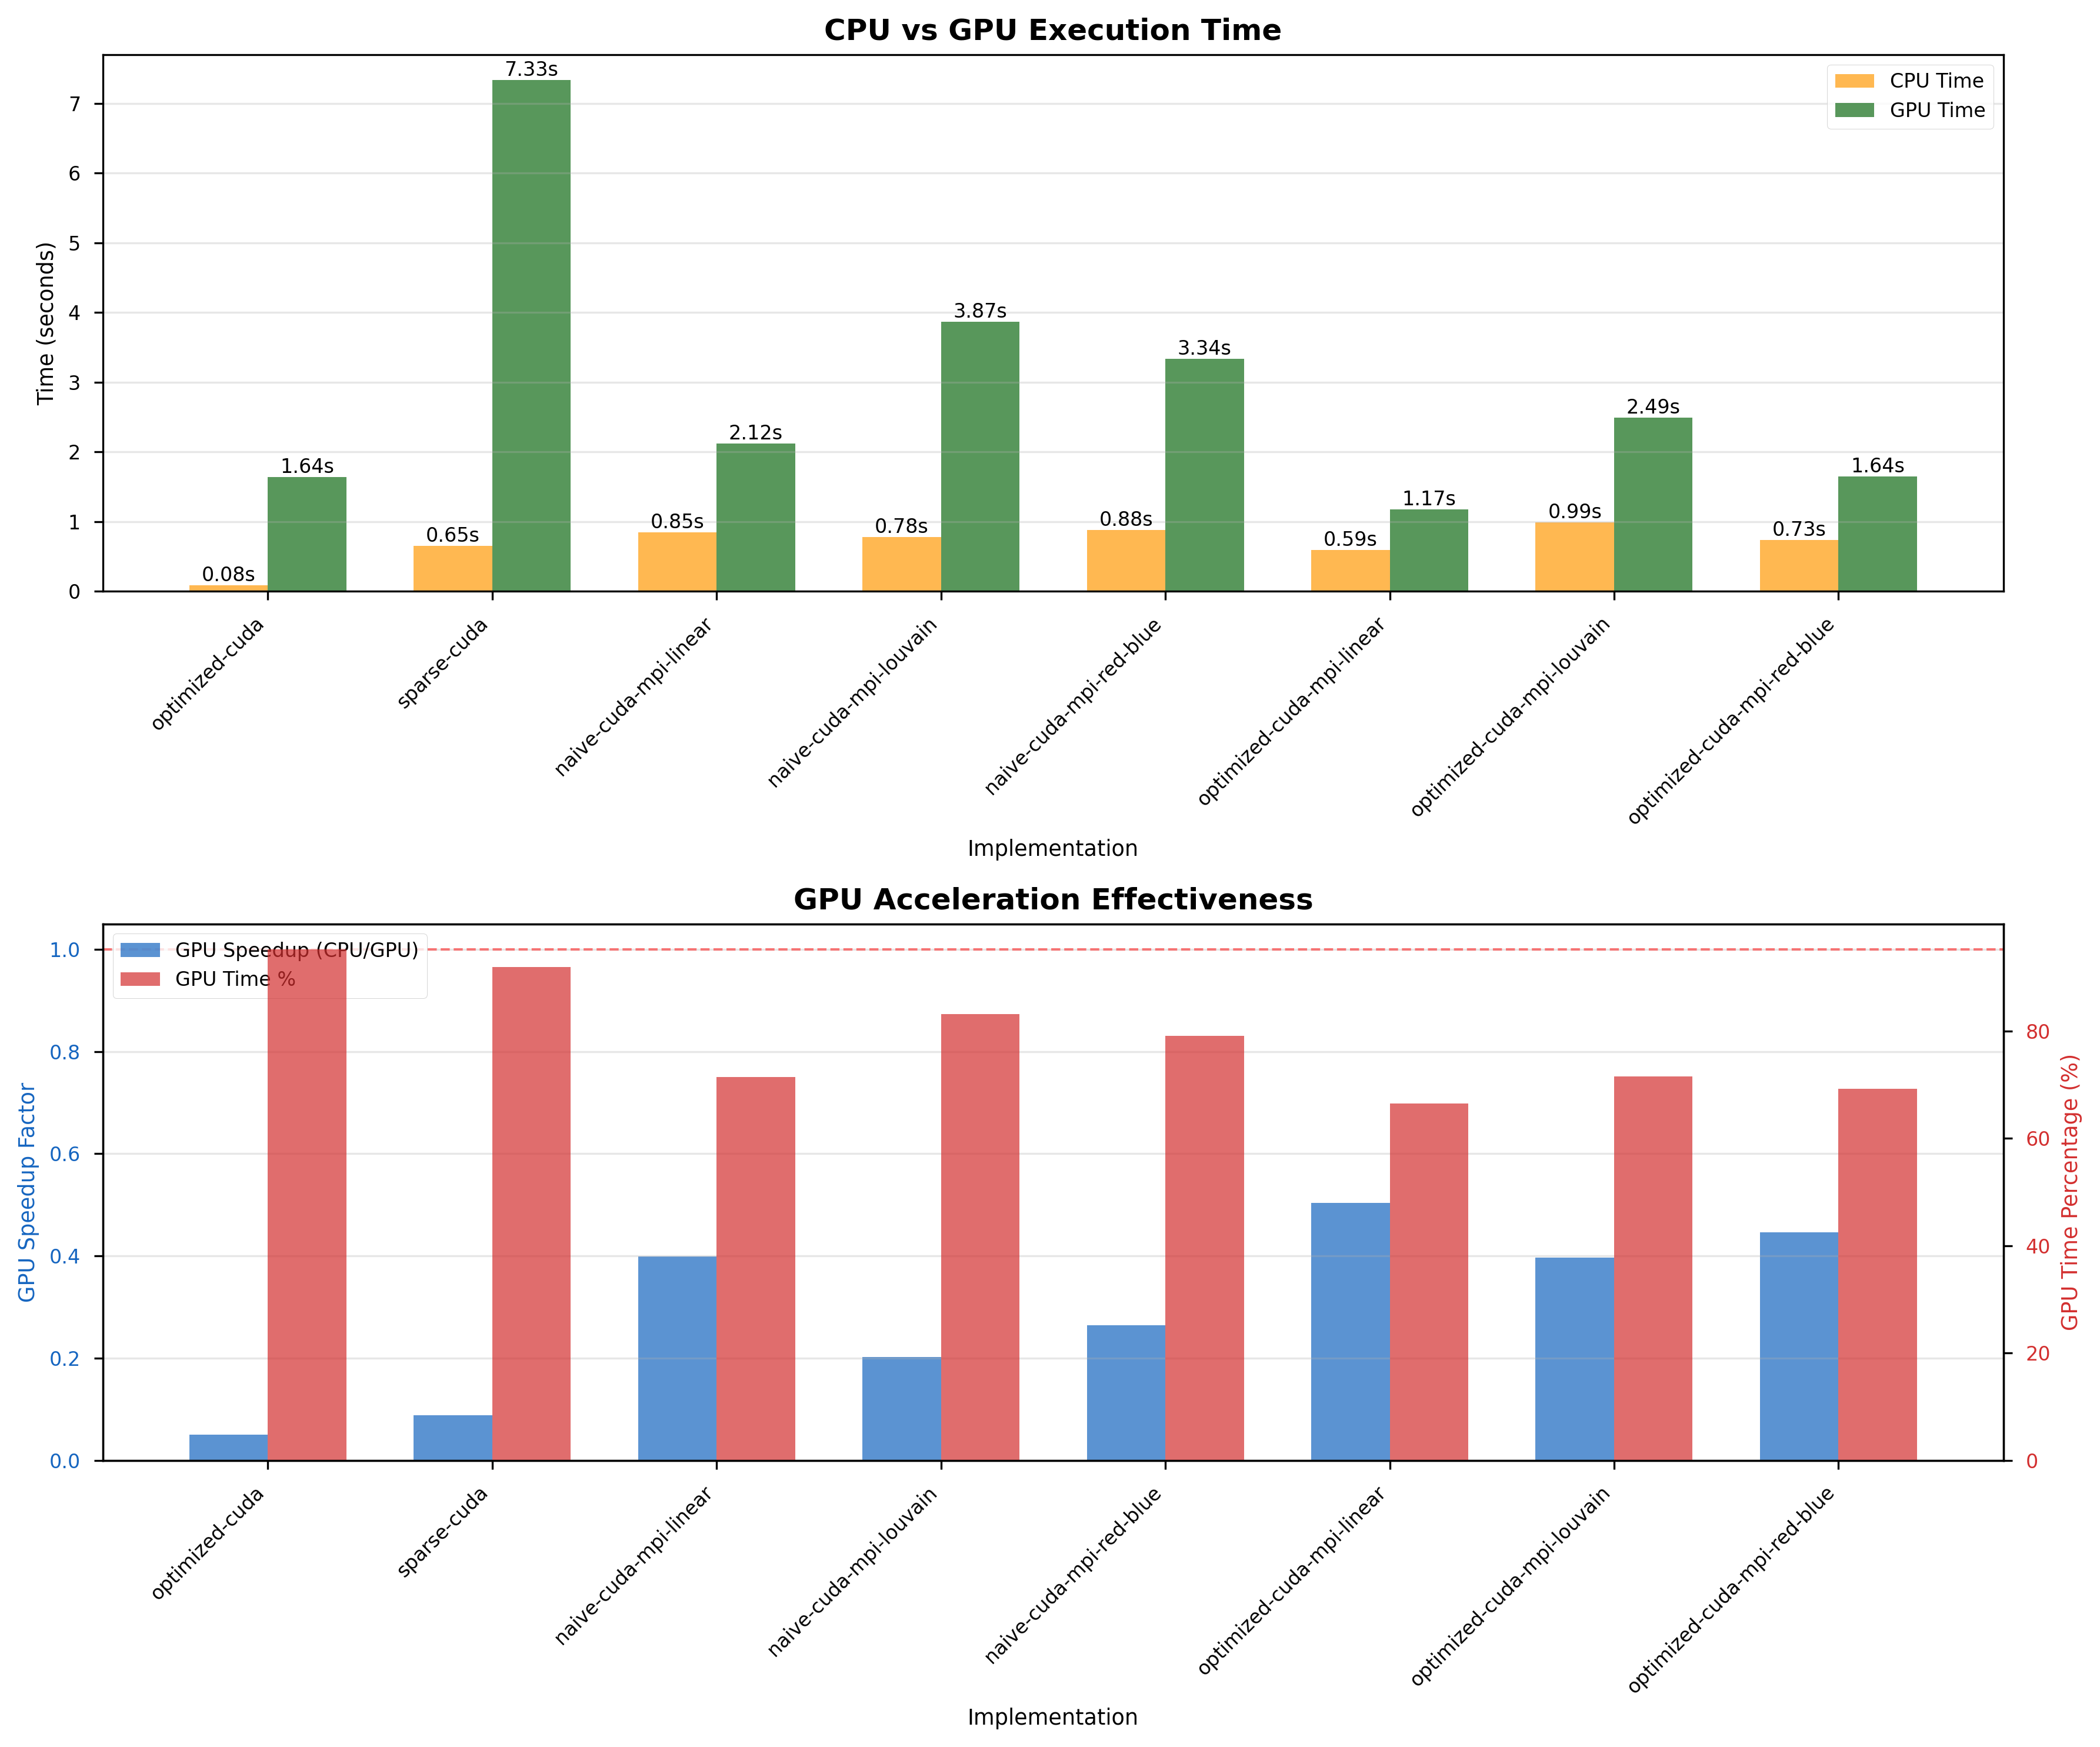


CPU vs GPU Analysis:

optimized-cuda:
  CPU Time:      0.083s (  4.8%)
  GPU Time:      1.637s ( 95.2%)
  GPU Speedup:   0.05x (CPU/GPU ratio)

sparse-cuda:
  CPU Time:      0.649s (  8.1%)
  GPU Time:      7.332s ( 91.9%)
  GPU Speedup:   0.09x (CPU/GPU ratio)

naive-cuda-mpi-linear:
  CPU Time:      0.848s ( 28.5%)
  GPU Time:      2.122s ( 71.5%)
  GPU Speedup:   0.40x (CPU/GPU ratio)
  MPI Time:      3.677s ( 55.3%)

naive-cuda-mpi-louvain:
  CPU Time:      0.782s ( 16.8%)
  GPU Time:      3.867s ( 83.2%)
  GPU Speedup:   0.20x (CPU/GPU ratio)
  MPI Time:      5.153s ( 52.6%)

naive-cuda-mpi-red-blue:
  CPU Time:      0.882s ( 20.9%)
  GPU Time:      3.337s ( 79.1%)
  GPU Speedup:   0.26x (CPU/GPU ratio)
  MPI Time:      9.001s ( 68.1%)

optimized-cuda-mpi-linear:
  CPU Time:      0.591s ( 33.5%)
  GPU Time:      1.174s ( 66.5%)
  GPU Speedup:   0.50x (CPU/GPU ratio)
  MPI Time:      2.031s ( 53.5%)

optimized-cuda-mpi-louvain:
  CPU Time:      0.989s ( 28.4%)
  GPU Time:      2.4

In [35]:
# CPU vs GPU Time Comparison
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Prepare data for CPU vs GPU comparison
cpu_gpu_data = []
for _, row in time_df.iterrows():
    cpu_gpu_data.append({
        'implementation': row['implementation'],
        'CPU': row['cpu_compute'],
        'GPU': row['cuda_kernel'] + row['cuda_memory'],
        'MPI': row['mpi']
    })

cpu_gpu_df = pd.DataFrame(cpu_gpu_data)

# Plot 1: Absolute time comparison
ax = axes[0]
x = range(len(cpu_gpu_df))
width = 0.35

cpu_bars = ax.bar([i - width/2 for i in x], cpu_gpu_df['CPU'], width, 
                   label='CPU Time', color='#FFA726', alpha=0.8)
gpu_bars = ax.bar([i + width/2 for i in x], cpu_gpu_df['GPU'], width,
                   label='GPU Time', color='#2E7D32', alpha=0.8)

ax.set_xlabel('Implementation')
ax.set_ylabel('Time (seconds)')
ax.set_title('CPU vs GPU Execution Time', fontweight='bold', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(cpu_gpu_df['implementation'], rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bars in [cpu_bars, gpu_bars]:
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{height:.2f}s',
                   ha='center', va='bottom', fontsize=8)

# Plot 2: CPU/GPU ratio and speedup
ax = axes[1]
cpu_gpu_df['GPU_Speedup'] = cpu_gpu_df['CPU'] / cpu_gpu_df['GPU']
cpu_gpu_df['GPU_Percentage'] = (cpu_gpu_df['GPU'] / (cpu_gpu_df['CPU'] + cpu_gpu_df['GPU']) * 100)

# Create dual-axis plot
ax_speedup = ax
ax_percentage = ax.twinx()

x_pos = range(len(cpu_gpu_df))
speedup_bars = ax_speedup.bar([i - width/2 for i in x_pos], cpu_gpu_df['GPU_Speedup'], 
                               width, label='GPU Speedup (CPU/GPU)', color='#1565C0', alpha=0.7)
pct_bars = ax_percentage.bar([i + width/2 for i in x_pos], cpu_gpu_df['GPU_Percentage'],
                              width, label='GPU Time %', color='#D32F2F', alpha=0.7)

ax_speedup.set_xlabel('Implementation')
ax_speedup.set_ylabel('GPU Speedup Factor', color='#1565C0')
ax_speedup.tick_params(axis='y', labelcolor='#1565C0')
ax_speedup.set_xticks(x_pos)
ax_speedup.set_xticklabels(cpu_gpu_df['implementation'], rotation=45, ha='right')
ax_speedup.set_title('GPU Acceleration Effectiveness', fontweight='bold', fontsize=12)
ax_speedup.grid(axis='y', alpha=0.3)
ax_speedup.axhline(y=1, color='red', linestyle='--', alpha=0.5, linewidth=1)

ax_percentage.set_ylabel('GPU Time Percentage (%)', color='#D32F2F')
ax_percentage.tick_params(axis='y', labelcolor='#D32F2F')

# Add legends
lines_1, labels_1 = ax_speedup.get_legend_handles_labels()
lines_2, labels_2 = ax_percentage.get_legend_handles_labels()
ax_speedup.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'cpu_vs_gpu_comparison.pdf', bbox_inches='tight')
plt.savefig(OUTPUT_DIR / 'cpu_vs_gpu_comparison.png', bbox_inches='tight')
plt.show()

print("\n" + "="*80)
print("CPU vs GPU Analysis:")
print("="*80)
for _, row in cpu_gpu_df.iterrows():
    total = row['CPU'] + row['GPU']
    if total > 0:
        print(f"\n{row['implementation']}:")
        print(f"  CPU Time:      {row['CPU']:.3f}s ({row['CPU']/total*100:5.1f}%)")
        print(f"  GPU Time:      {row['GPU']:.3f}s ({row['GPU']/total*100:5.1f}%)")
        if row['GPU'] > 0:
            print(f"  GPU Speedup:   {row['GPU_Speedup']:.2f}x (CPU/GPU ratio)")
        if row['MPI'] > 0:
            print(f"  MPI Time:      {row['MPI']:.3f}s ({row['MPI']/(total+row['MPI'])*100:5.1f}%)")
print("="*80)

## Visualization 1: Time Distribution - CPU vs CUDA vs MPI

**Purpose**: Shows the fundamental architecture benefit of GPU acceleration and identifies MPI communication overhead in distributed implementations.

Extracting time breakdown with CPU data from SQLite databases...
SQLite database not found for optimized-cuda rank 0
SQLite database not found for sparse-cuda rank 0


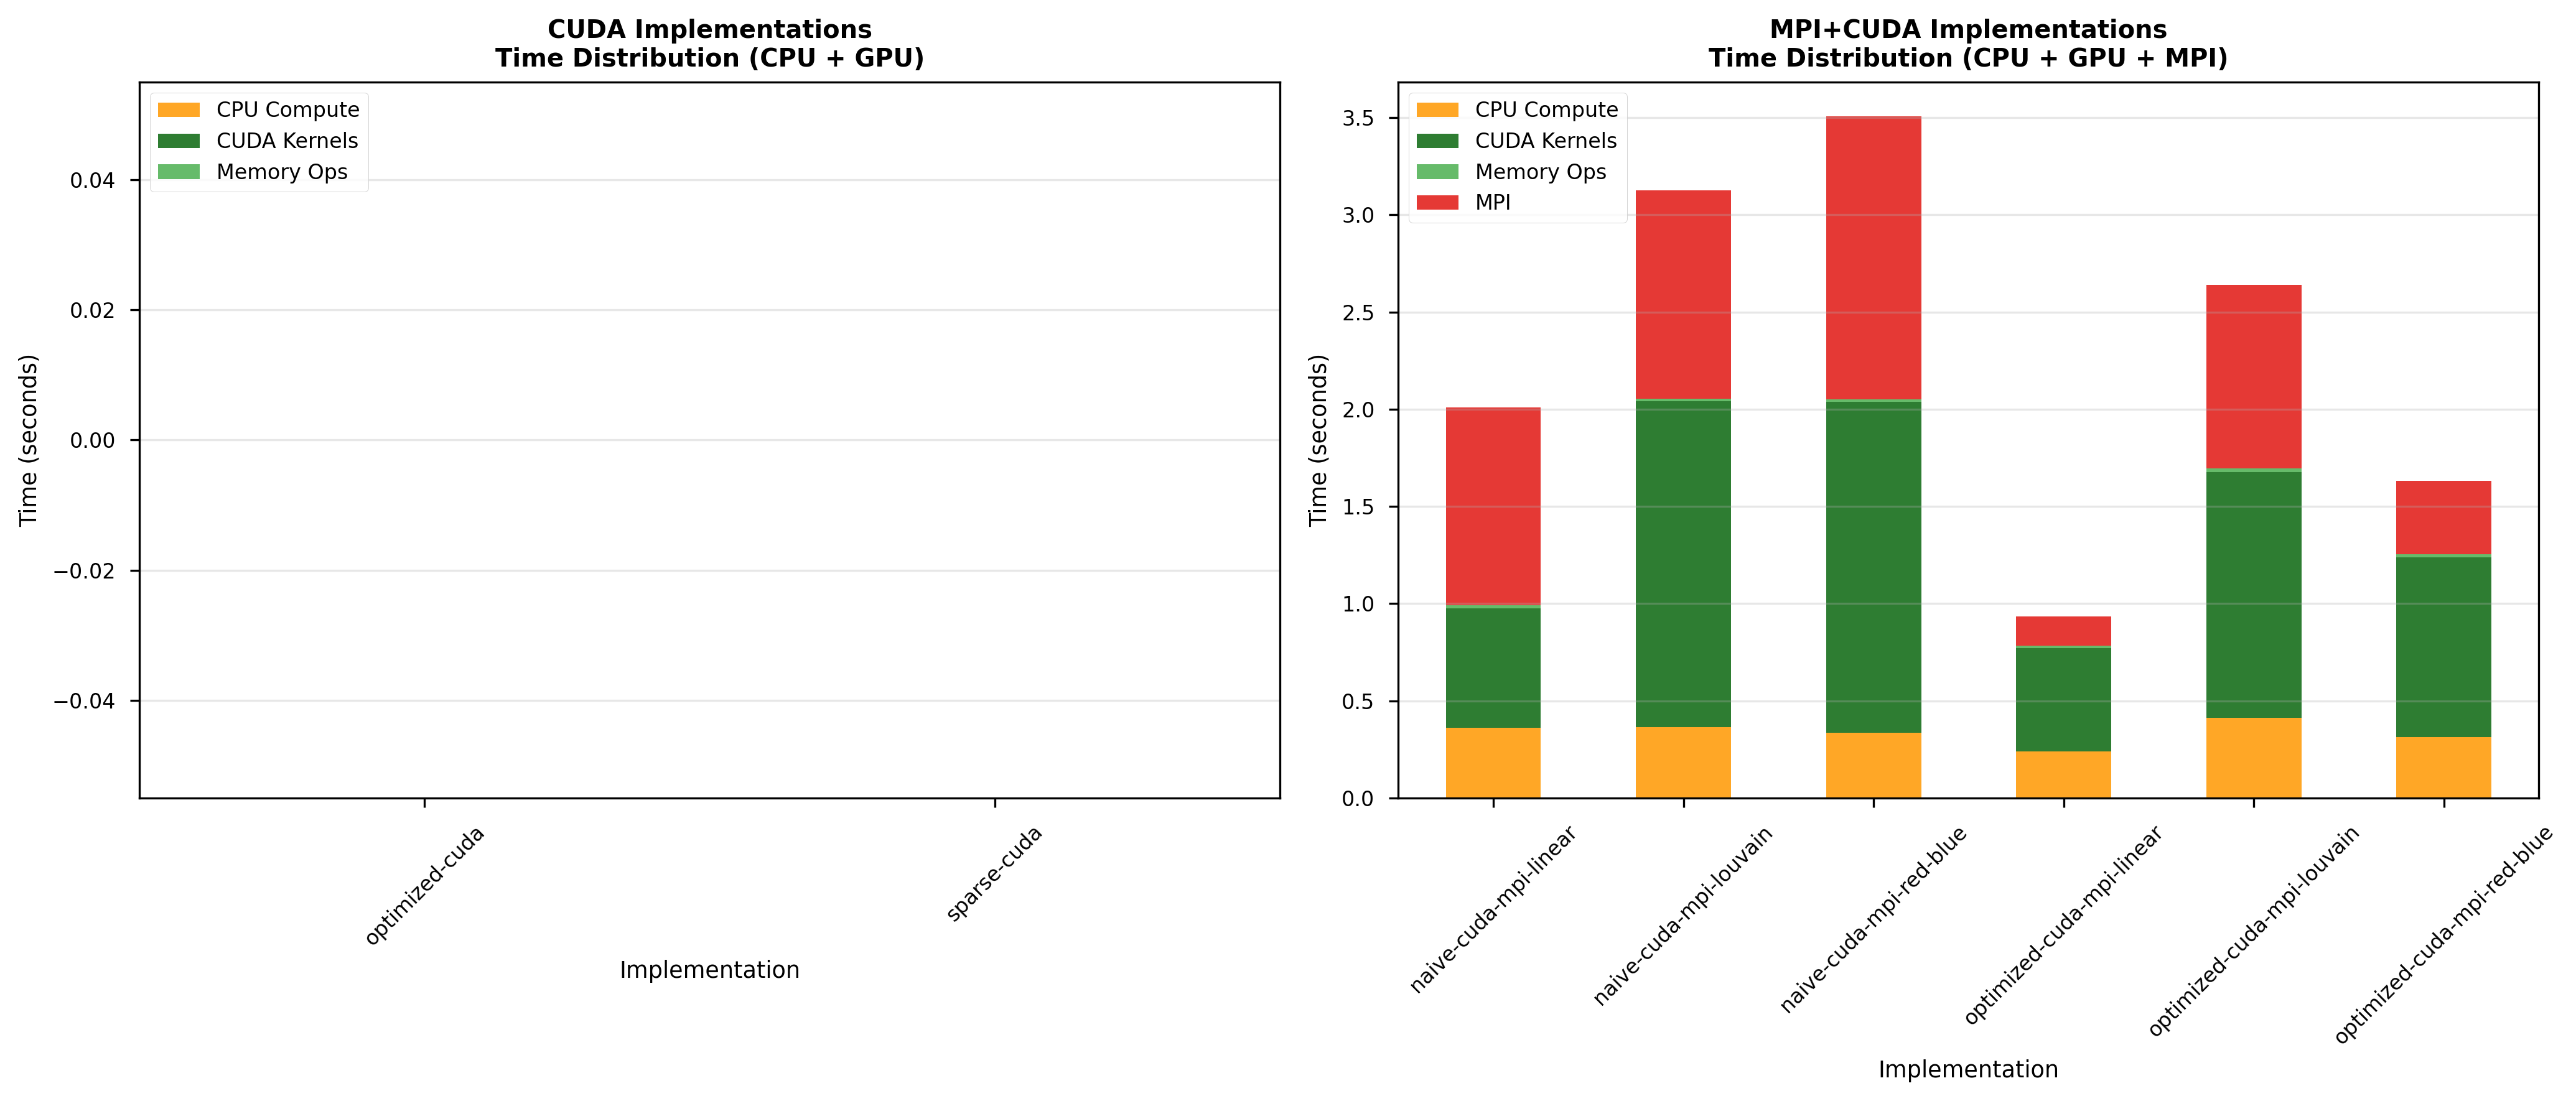


Time Distribution Summary with CPU (seconds):
             implementation  cpu_compute  cuda_kernel  cuda_memory      mpi    total
             optimized-cuda     0.000000     0.000000     0.000000 0.000000 0.000000
                sparse-cuda     0.000000     0.000000     0.000000 0.000000 0.000000
      naive-cuda-mpi-linear     0.359690     0.616638     0.013335 1.018822 2.008486
     naive-cuda-mpi-louvain     0.364483     1.674921     0.014945 1.072283 3.126632
    naive-cuda-mpi-red-blue     0.336401     1.701001     0.013735 1.455482 3.506620
  optimized-cuda-mpi-linear     0.239216     0.531646     0.011993 0.152367 0.935223
 optimized-cuda-mpi-louvain     0.413214     1.262268     0.020545 0.944905 2.640932
optimized-cuda-mpi-red-blue     0.312767     0.923351     0.018069 0.375761 1.629948


Percentage Breakdown:

naive-cuda-mpi-linear:
  CPU Compute:   17.9%
  CUDA Kernels:  30.7%
  CUDA Memory:    0.7%
  MPI:           50.7%

naive-cuda-mpi-louvain:
  CPU Compute:   11.7%


In [36]:
# Calculate time breakdown for all implementations (including CPU time from SQLite)
print("Extracting time breakdown with CPU data from SQLite databases...")
time_breakdown = []
for impl in ALL_IMPLS:
    breakdown = get_detailed_time_breakdown(impl)
    if breakdown:
        time_breakdown.append({
            'implementation': impl,
            'cpu_compute': breakdown.get('cpu_compute_s', 0),
            'cuda_kernel': breakdown.get('cuda_kernel_s', 0),
            'cuda_memory': breakdown.get('cuda_memory_s', 0),
            'mpi': breakdown.get('mpi_s', 0),
            'total': breakdown.get('total_execution_s', 0)
        })

time_df = pd.DataFrame(time_breakdown)

# Create figure with subplots for CUDA and MPI implementations
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: CUDA-only implementations
cuda_data = time_df[time_df['implementation'].isin(CUDA_IMPLS)]
if not cuda_data.empty:
    ax = axes[0]
    cuda_plot_data = cuda_data.set_index('implementation')[['cpu_compute', 'cuda_kernel', 'cuda_memory']]
    cuda_plot_data.plot(kind='bar', stacked=True, ax=ax, 
                        color=['#FFA726', '#2E7D32', '#66BB6A'])
    ax.set_title('CUDA Implementations\nTime Distribution (CPU + GPU)', fontweight='bold')
    ax.set_xlabel('Implementation')
    ax.set_ylabel('Time (seconds)')
    ax.legend(['CPU Compute', 'CUDA Kernels', 'Memory Ops'], loc='upper left')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='y', alpha=0.3)

# Plot 2: MPI+CUDA implementations
mpi_data = time_df[time_df['implementation'].isin(MPI_IMPLS)]
if not mpi_data.empty:
    ax = axes[1]
    mpi_plot_data = mpi_data.set_index('implementation')[['cpu_compute', 'cuda_kernel', 'cuda_memory', 'mpi']]
    mpi_plot_data.plot(kind='bar', stacked=True, ax=ax,
                       color=['#FFA726', '#2E7D32', '#66BB6A', '#E53935'])
    ax.set_title('MPI+CUDA Implementations\nTime Distribution (CPU + GPU + MPI)', fontweight='bold')
    ax.set_xlabel('Implementation')
    ax.set_ylabel('Time (seconds)')
    ax.legend(['CPU Compute', 'CUDA Kernels', 'Memory Ops', 'MPI'], loc='upper left')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'time_distribution_with_cpu.pdf', bbox_inches='tight')
plt.savefig(OUTPUT_DIR / 'time_distribution_with_cpu.png', bbox_inches='tight')
plt.show()

print("\nTime Distribution Summary with CPU (seconds):")
print(time_df.to_string(index=False))

# Show percentage breakdown
print("\n\nPercentage Breakdown:")
for _, row in time_df.iterrows():
    total = row['total']
    if total > 0:
        print(f"\n{row['implementation']}:")
        print(f"  CPU Compute:  {row['cpu_compute']/total*100:5.1f}%")
        print(f"  CUDA Kernels: {row['cuda_kernel']/total*100:5.1f}%")
        print(f"  CUDA Memory:  {row['cuda_memory']/total*100:5.1f}%")
        if row['mpi'] > 0:
            print(f"  MPI:          {row['mpi']/total*100:5.1f}%")

## Visualization 5: Kernel Performance Breakdown

**Purpose**: Identifies which kernels dominate execution time and shows optimization effectiveness.

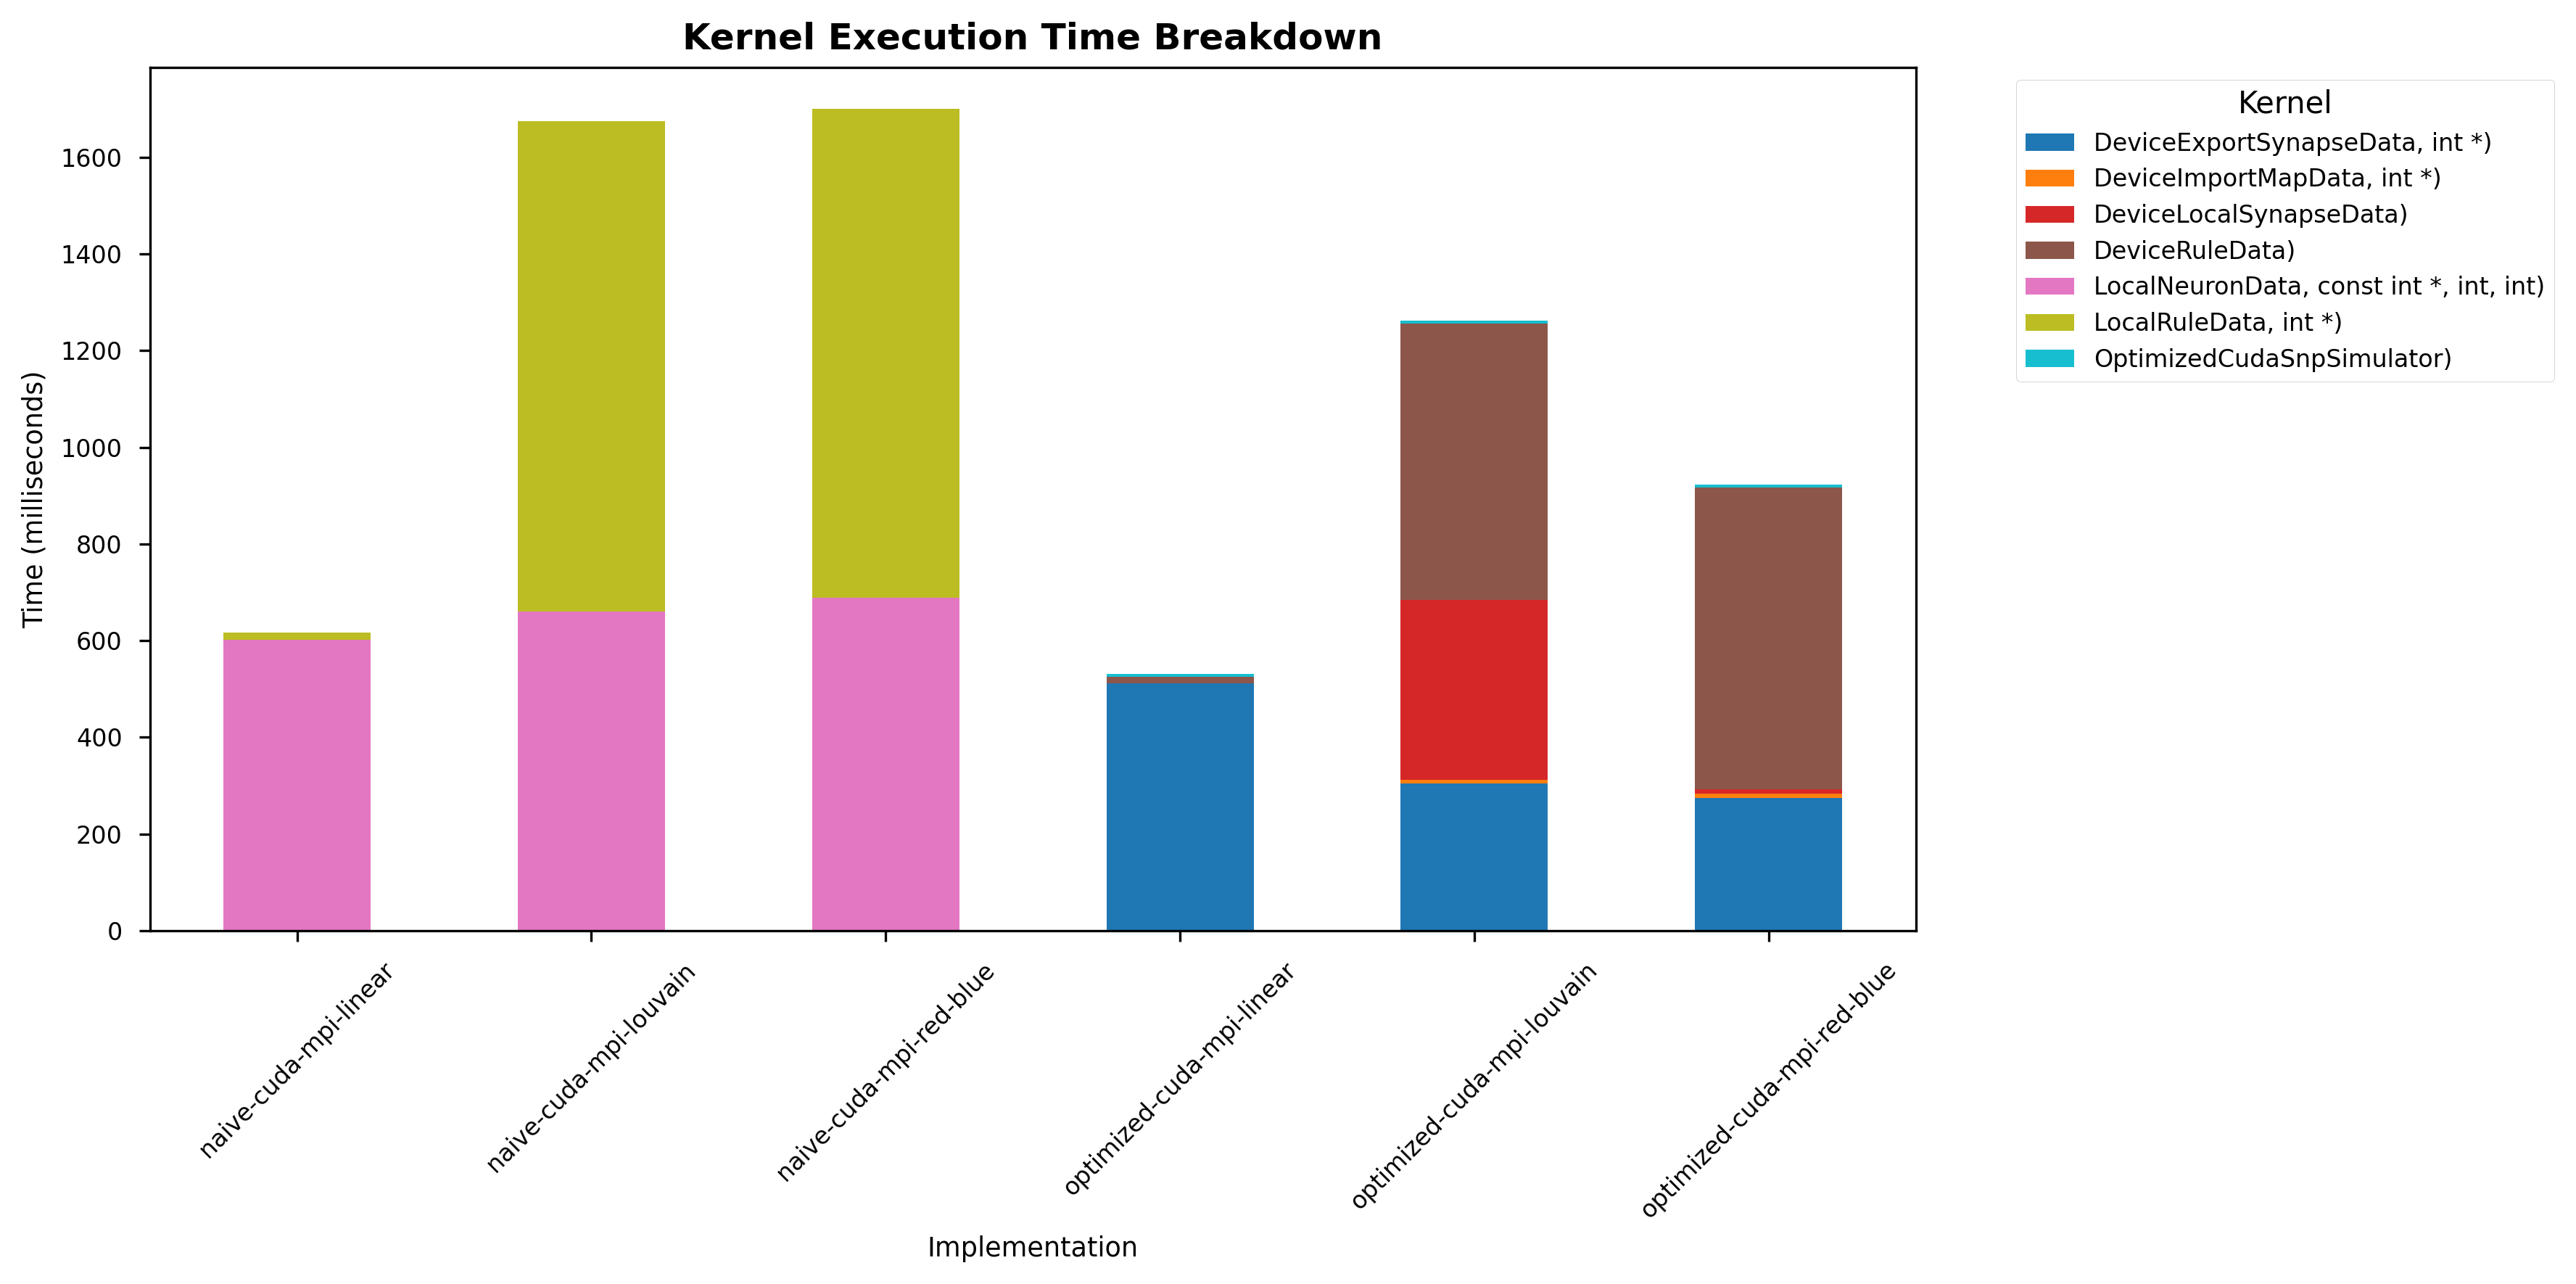


Top 3 kernels by time for each implementation:

naive-cuda-mpi-linear:
  LocalNeuronData, const int *, int, int): 602.09 ms (97.6%)
  LocalRuleData, int *): 14.55 ms (2.4%)

naive-cuda-mpi-louvain:
  LocalRuleData, int *): 1015.28 ms (60.6%)
  LocalNeuronData, const int *, int, int): 659.64 ms (39.4%)

naive-cuda-mpi-red-blue:
  LocalRuleData, int *): 1012.48 ms (59.5%)
  LocalNeuronData, const int *, int, int): 688.52 ms (40.5%)

optimized-cuda-mpi-linear:
  DeviceExportSynapseData, int *): 510.98 ms (96.1%)
  DeviceRuleData): 13.87 ms (2.6%)
  OptimizedCudaSnpSimulator): 6.80 ms (1.3%)

optimized-cuda-mpi-louvain:
  DeviceRuleData): 571.16 ms (45.2%)
  DeviceLocalSynapseData): 372.68 ms (29.5%)
  DeviceExportSynapseData, int *): 303.67 ms (24.1%)

optimized-cuda-mpi-red-blue:
  DeviceRuleData): 623.83 ms (67.6%)
  DeviceExportSynapseData, int *): 273.70 ms (29.6%)
  DeviceLocalSynapseData): 9.92 ms (1.1%)


In [37]:
# Load kernel data for all implementations
kernel_data = load_all_implementations("stats_cuda_gpu_kern_sum.csv")

# Process and prepare data
kernel_times = []
for impl, df in kernel_data.items():
    if df is not None and not df.empty:
        for _, row in df.iterrows():
            kernel_name = row['Name'].split('::')[-1].replace('(<unnamed>', '').split('(')[0]
            kernel_times.append({
                'implementation': impl,
                'kernel': kernel_name,
                'time_ms': row['Total Time (ns)'] / 1e6,
                'percentage': row['Time (%)']
            })

kernel_df = pd.DataFrame(kernel_times)

if not kernel_df.empty:
    # Create pivot table for stacked bar chart
    pivot_data = kernel_df.pivot_table(index='implementation', columns='kernel', 
                                       values='time_ms', fill_value=0)
    
    # Plot
    fig, ax = plt.subplots(figsize=(12, 6))
    pivot_data.plot(kind='bar', stacked=True, ax=ax, colormap='tab10')
    ax.set_title('Kernel Execution Time Breakdown', fontweight='bold', fontsize=12)
    ax.set_xlabel('Implementation')
    ax.set_ylabel('Time (milliseconds)')
    ax.legend(title='Kernel', bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'kernel_breakdown.pdf', bbox_inches='tight')
    plt.savefig(OUTPUT_DIR / 'kernel_breakdown.png', bbox_inches='tight')
    plt.show()
    
    print("\nTop 3 kernels by time for each implementation:")
    for impl in kernel_df['implementation'].unique():
        impl_data = kernel_df[kernel_df['implementation'] == impl].nlargest(3, 'time_ms')
        print(f"\n{impl}:")
        for _, row in impl_data.iterrows():
            print(f"  {row['kernel']}: {row['time_ms']:.2f} ms ({row['percentage']:.1f}%)")
else:
    print("No kernel data available.")

## Visualization 6: MPI Communication Analysis

**Purpose**: Quantifies MPI overhead and shows the impact of different communication patterns.

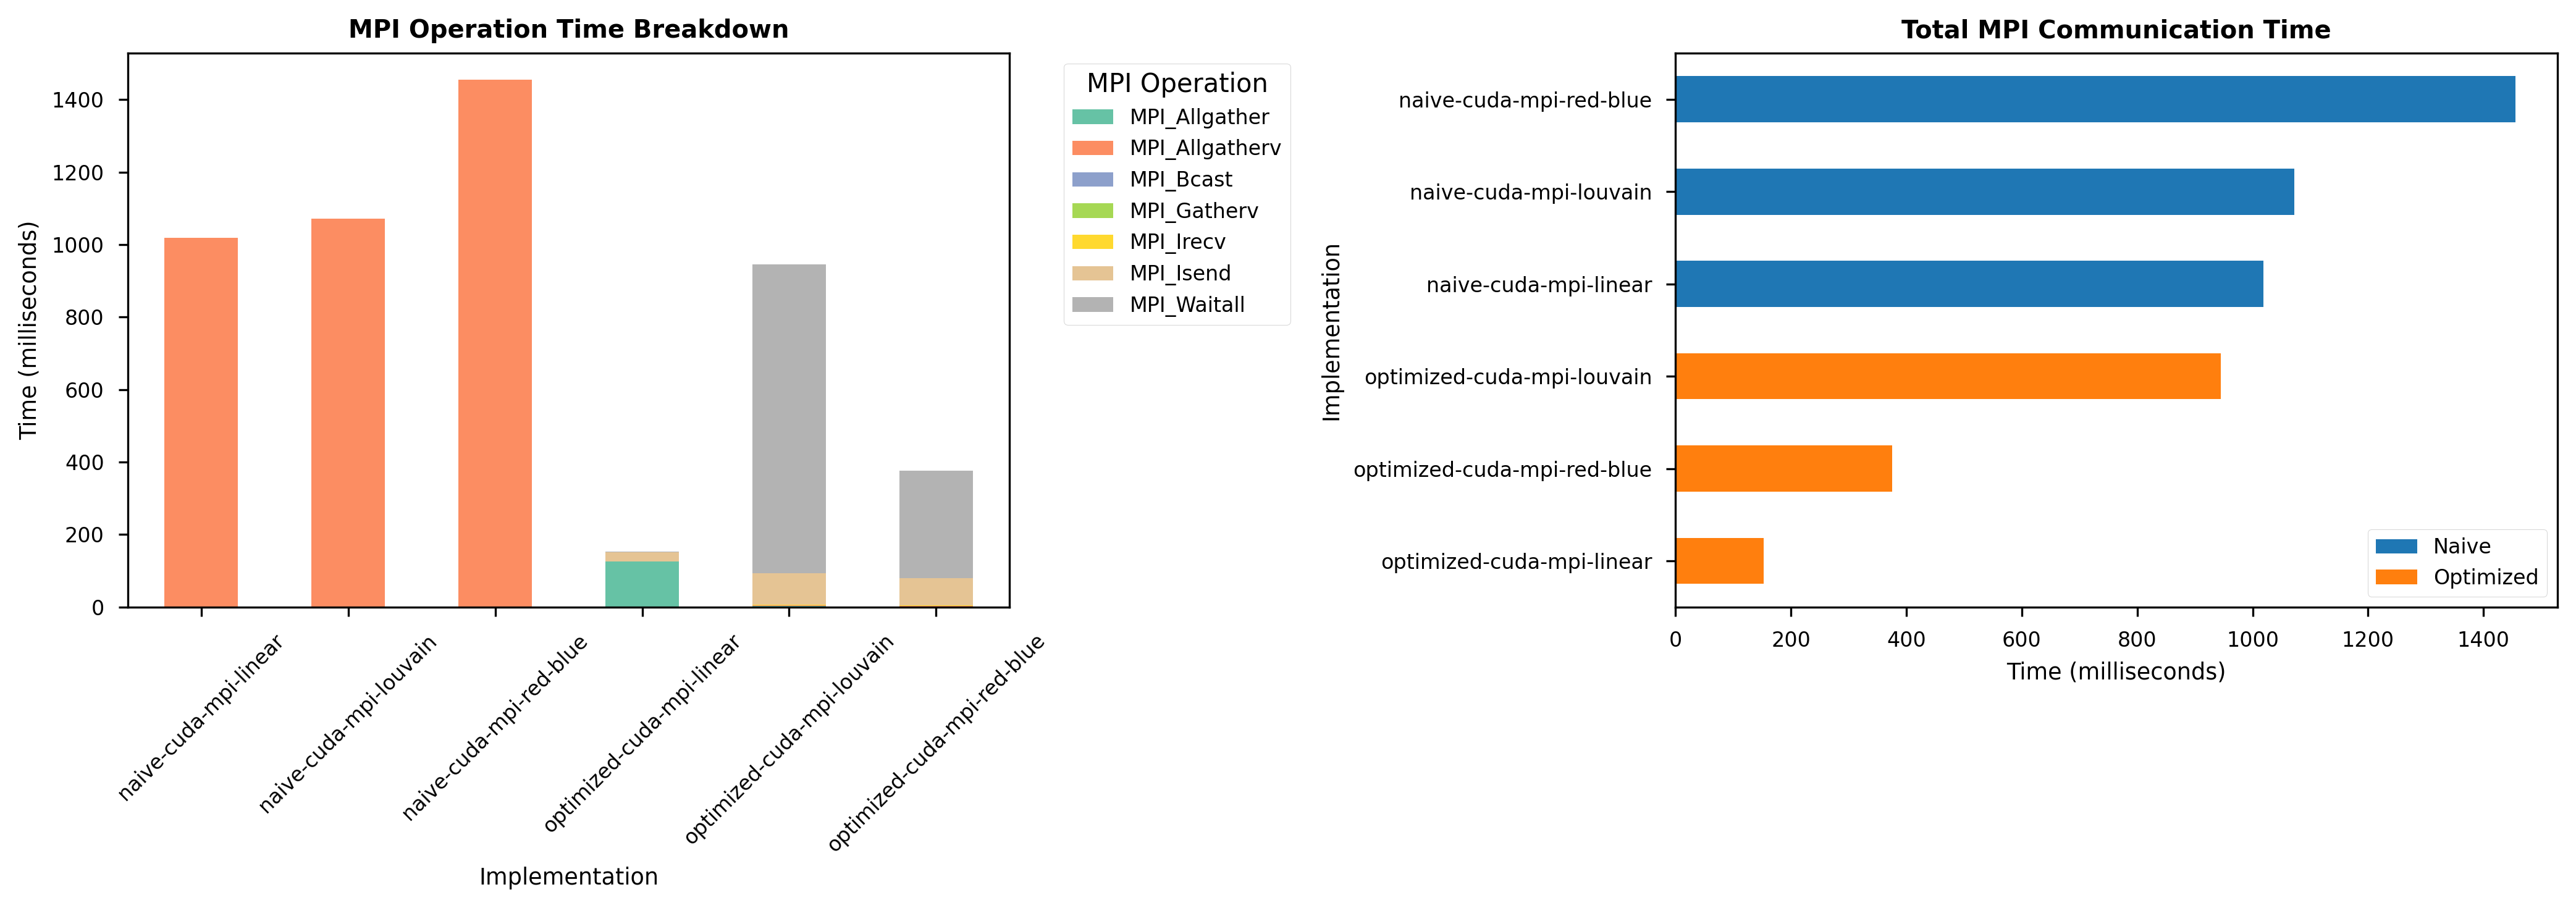


MPI Communication Summary:
implementation
optimized-cuda-mpi-linear       152.367476
optimized-cuda-mpi-red-blue     375.760612
optimized-cuda-mpi-louvain      944.904838
naive-cuda-mpi-linear          1018.822428
naive-cuda-mpi-louvain         1072.283478
naive-cuda-mpi-red-blue        1455.482344


In [38]:
# Load MPI event data
mpi_data = load_all_implementations("stats_mpi_event_sum.csv")

# Process MPI operations
mpi_operations = []
for impl, df in mpi_data.items():
    if df is not None and not df.empty:
        for _, row in df.iterrows():
            mpi_operations.append({
                'implementation': impl,
                'operation': row['Name'],
                'time_ms': row['Total Time (ns)'] / 1e6,
                'percentage': row['Time (%)']
            })

mpi_op_df = pd.DataFrame(mpi_operations)

if not mpi_op_df.empty:
    # Create figure with two subplots
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot 1: Stacked bar chart of MPI operations
    ax = axes[0]
    pivot_mpi = mpi_op_df.pivot_table(index='implementation', columns='operation',
                                      values='time_ms', fill_value=0)
    pivot_mpi.plot(kind='bar', stacked=True, ax=ax, colormap='Set2')
    ax.set_title('MPI Operation Time Breakdown', fontweight='bold')
    ax.set_xlabel('Implementation')
    ax.set_ylabel('Time (milliseconds)')
    ax.legend(title='MPI Operation', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    ax.tick_params(axis='x', rotation=45)
    
    # Plot 2: Total MPI time comparison
    ax = axes[1]
    total_mpi_time = mpi_op_df.groupby('implementation')['time_ms'].sum().sort_values()
    colors = ['#1f77b4' if 'naive' in impl else '#ff7f0e' for impl in total_mpi_time.index]
    total_mpi_time.plot(kind='barh', ax=ax, color=colors)
    ax.set_title('Total MPI Communication Time', fontweight='bold')
    ax.set_xlabel('Time (milliseconds)')
    ax.set_ylabel('Implementation')
    
    # Add legend for naive vs optimized
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor='#1f77b4', label='Naive'),
                      Patch(facecolor='#ff7f0e', label='Optimized')]
    ax.legend(handles=legend_elements, loc='lower right')
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'mpi_communication.pdf', bbox_inches='tight')
    plt.savefig(OUTPUT_DIR / 'mpi_communication.png', bbox_inches='tight')
    plt.show()
    
    print("\nMPI Communication Summary:")
    print(total_mpi_time.to_string())
else:
    print("No MPI data available.")

## Visualization 7: MPI Message Volume Analysis

**Purpose**: Shows data movement patterns and their relationship to communication time.

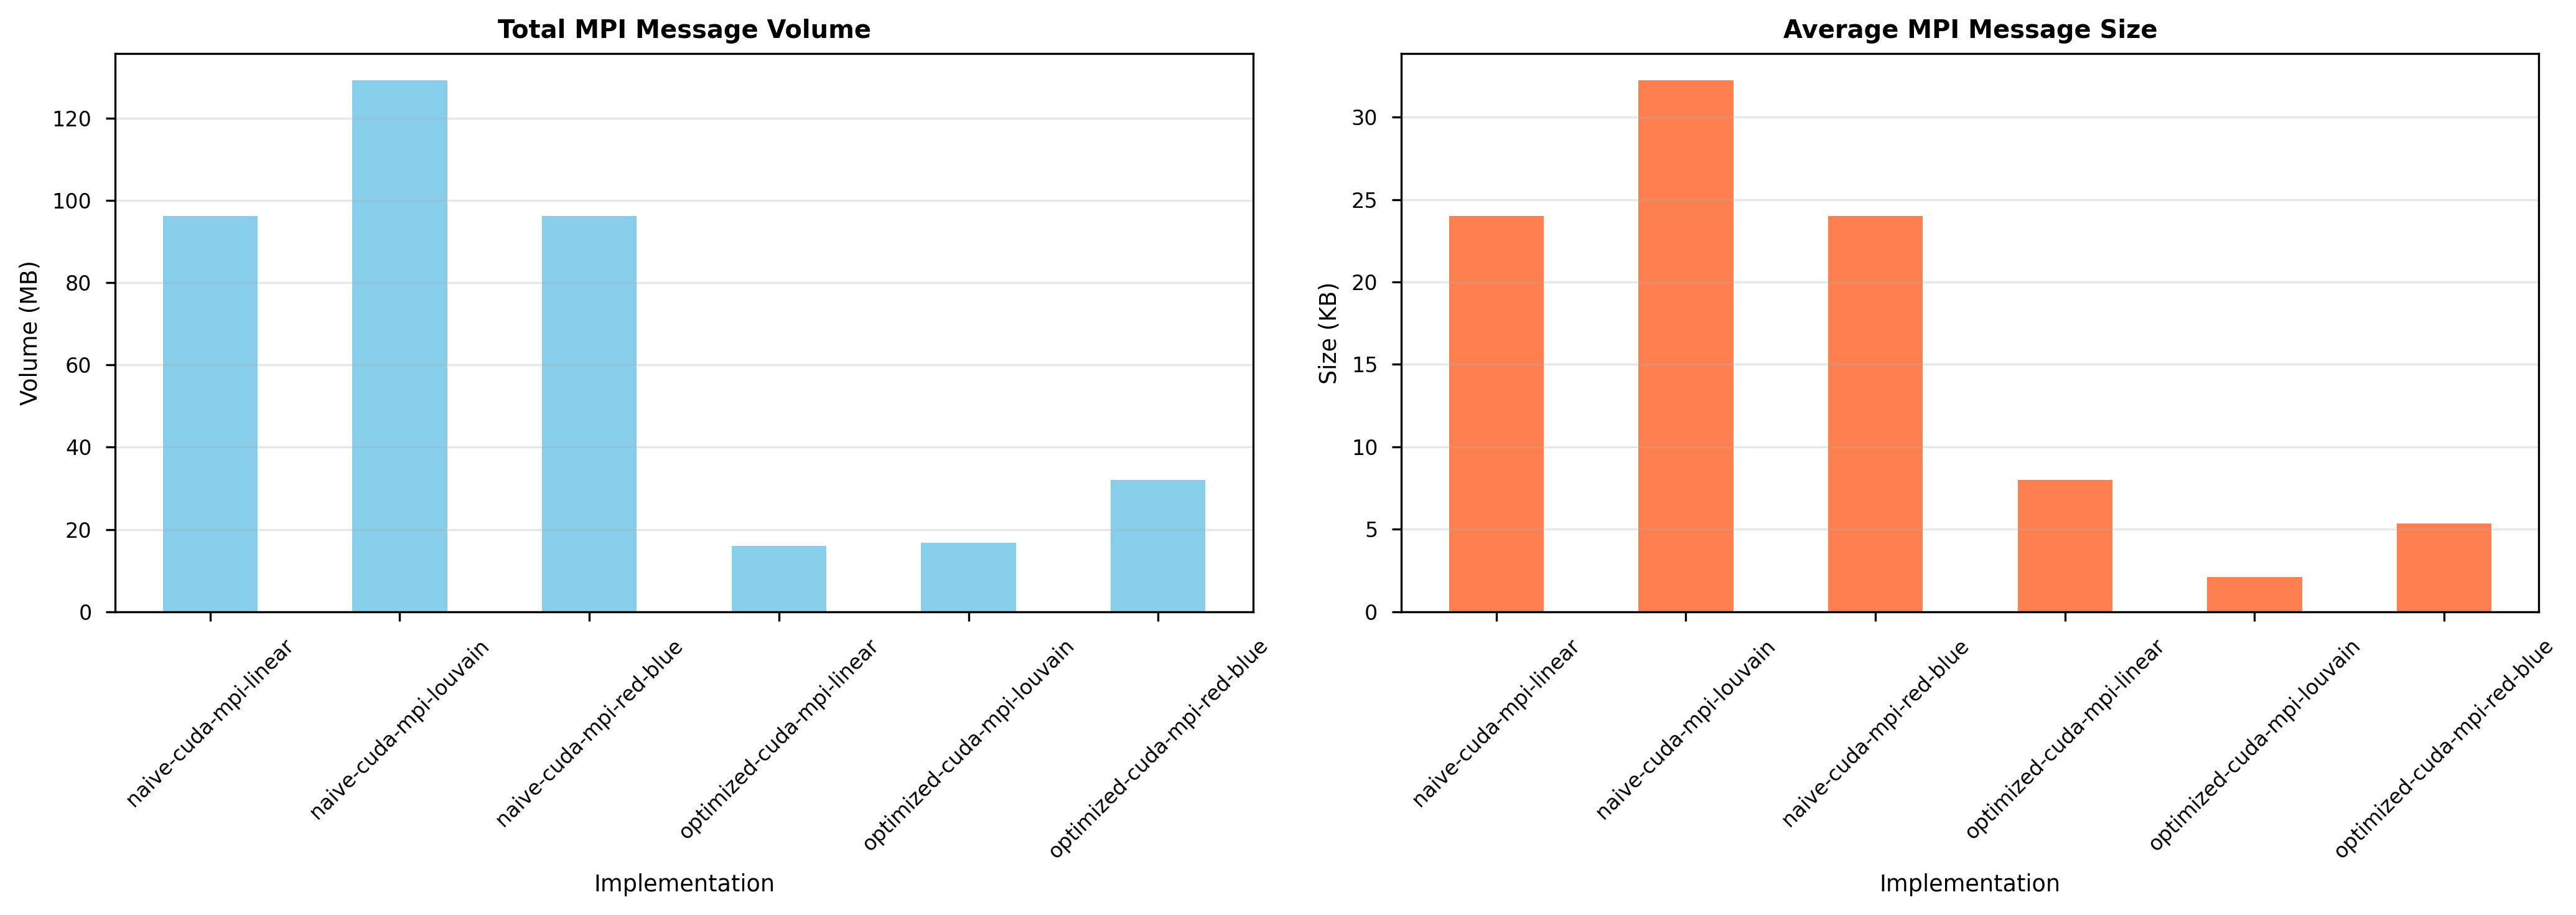


MPI Message Volume Summary:
             implementation  volume_mb  instances  avg_msg_size_kb
      naive-cuda-mpi-linear  96.218750       4104        24.007797
     naive-cuda-mpi-louvain 129.232883       4104        32.245242
    naive-cuda-mpi-red-blue  96.218750       4104        24.007797
  optimized-cuda-mpi-linear  16.062523       2054         8.007801
 optimized-cuda-mpi-louvain  16.727695       8204         2.087903
optimized-cuda-mpi-red-blue  32.078148       6154         5.337670


In [39]:
# Load MPI message size data
mpi_msg_data = load_all_implementations("stats_mpi_msg_size_sum.csv")

# Process message volumes
msg_volumes = []
for impl, df in mpi_msg_data.items():
    if df is not None and not df.empty:
        total_volume = df['Total Message Volume'].sum()
        msg_volumes.append({
            'implementation': impl,
            'volume_mb': total_volume / (1024 * 1024),
            'instances': df['Instances'].sum()
        })

msg_vol_df = pd.DataFrame(msg_volumes)

if not msg_vol_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot 1: Message volume by implementation
    ax = axes[0]
    msg_vol_df.set_index('implementation')['volume_mb'].plot(kind='bar', ax=ax, color='skyblue')
    ax.set_title('Total MPI Message Volume', fontweight='bold')
    ax.set_xlabel('Implementation')
    ax.set_ylabel('Volume (MB)')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='y', alpha=0.3)
    
    # Plot 2: Average message size
    ax = axes[1]
    msg_vol_df['avg_msg_size_kb'] = (msg_vol_df['volume_mb'] * 1024) / msg_vol_df['instances']
    msg_vol_df.set_index('implementation')['avg_msg_size_kb'].plot(kind='bar', ax=ax, color='coral')
    ax.set_title('Average MPI Message Size', fontweight='bold')
    ax.set_xlabel('Implementation')
    ax.set_ylabel('Size (KB)')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'mpi_message_volume.pdf', bbox_inches='tight')
    plt.savefig(OUTPUT_DIR / 'mpi_message_volume.png', bbox_inches='tight')
    plt.show()
    
    print("\nMPI Message Volume Summary:")
    print(msg_vol_df.to_string(index=False))
else:
    print("No MPI message data available.")

## Visualization 8: Partitioning Strategy Comparison

**Purpose**: Key contribution - compares linear, Louvain, and Red-Blue partitioning strategies.

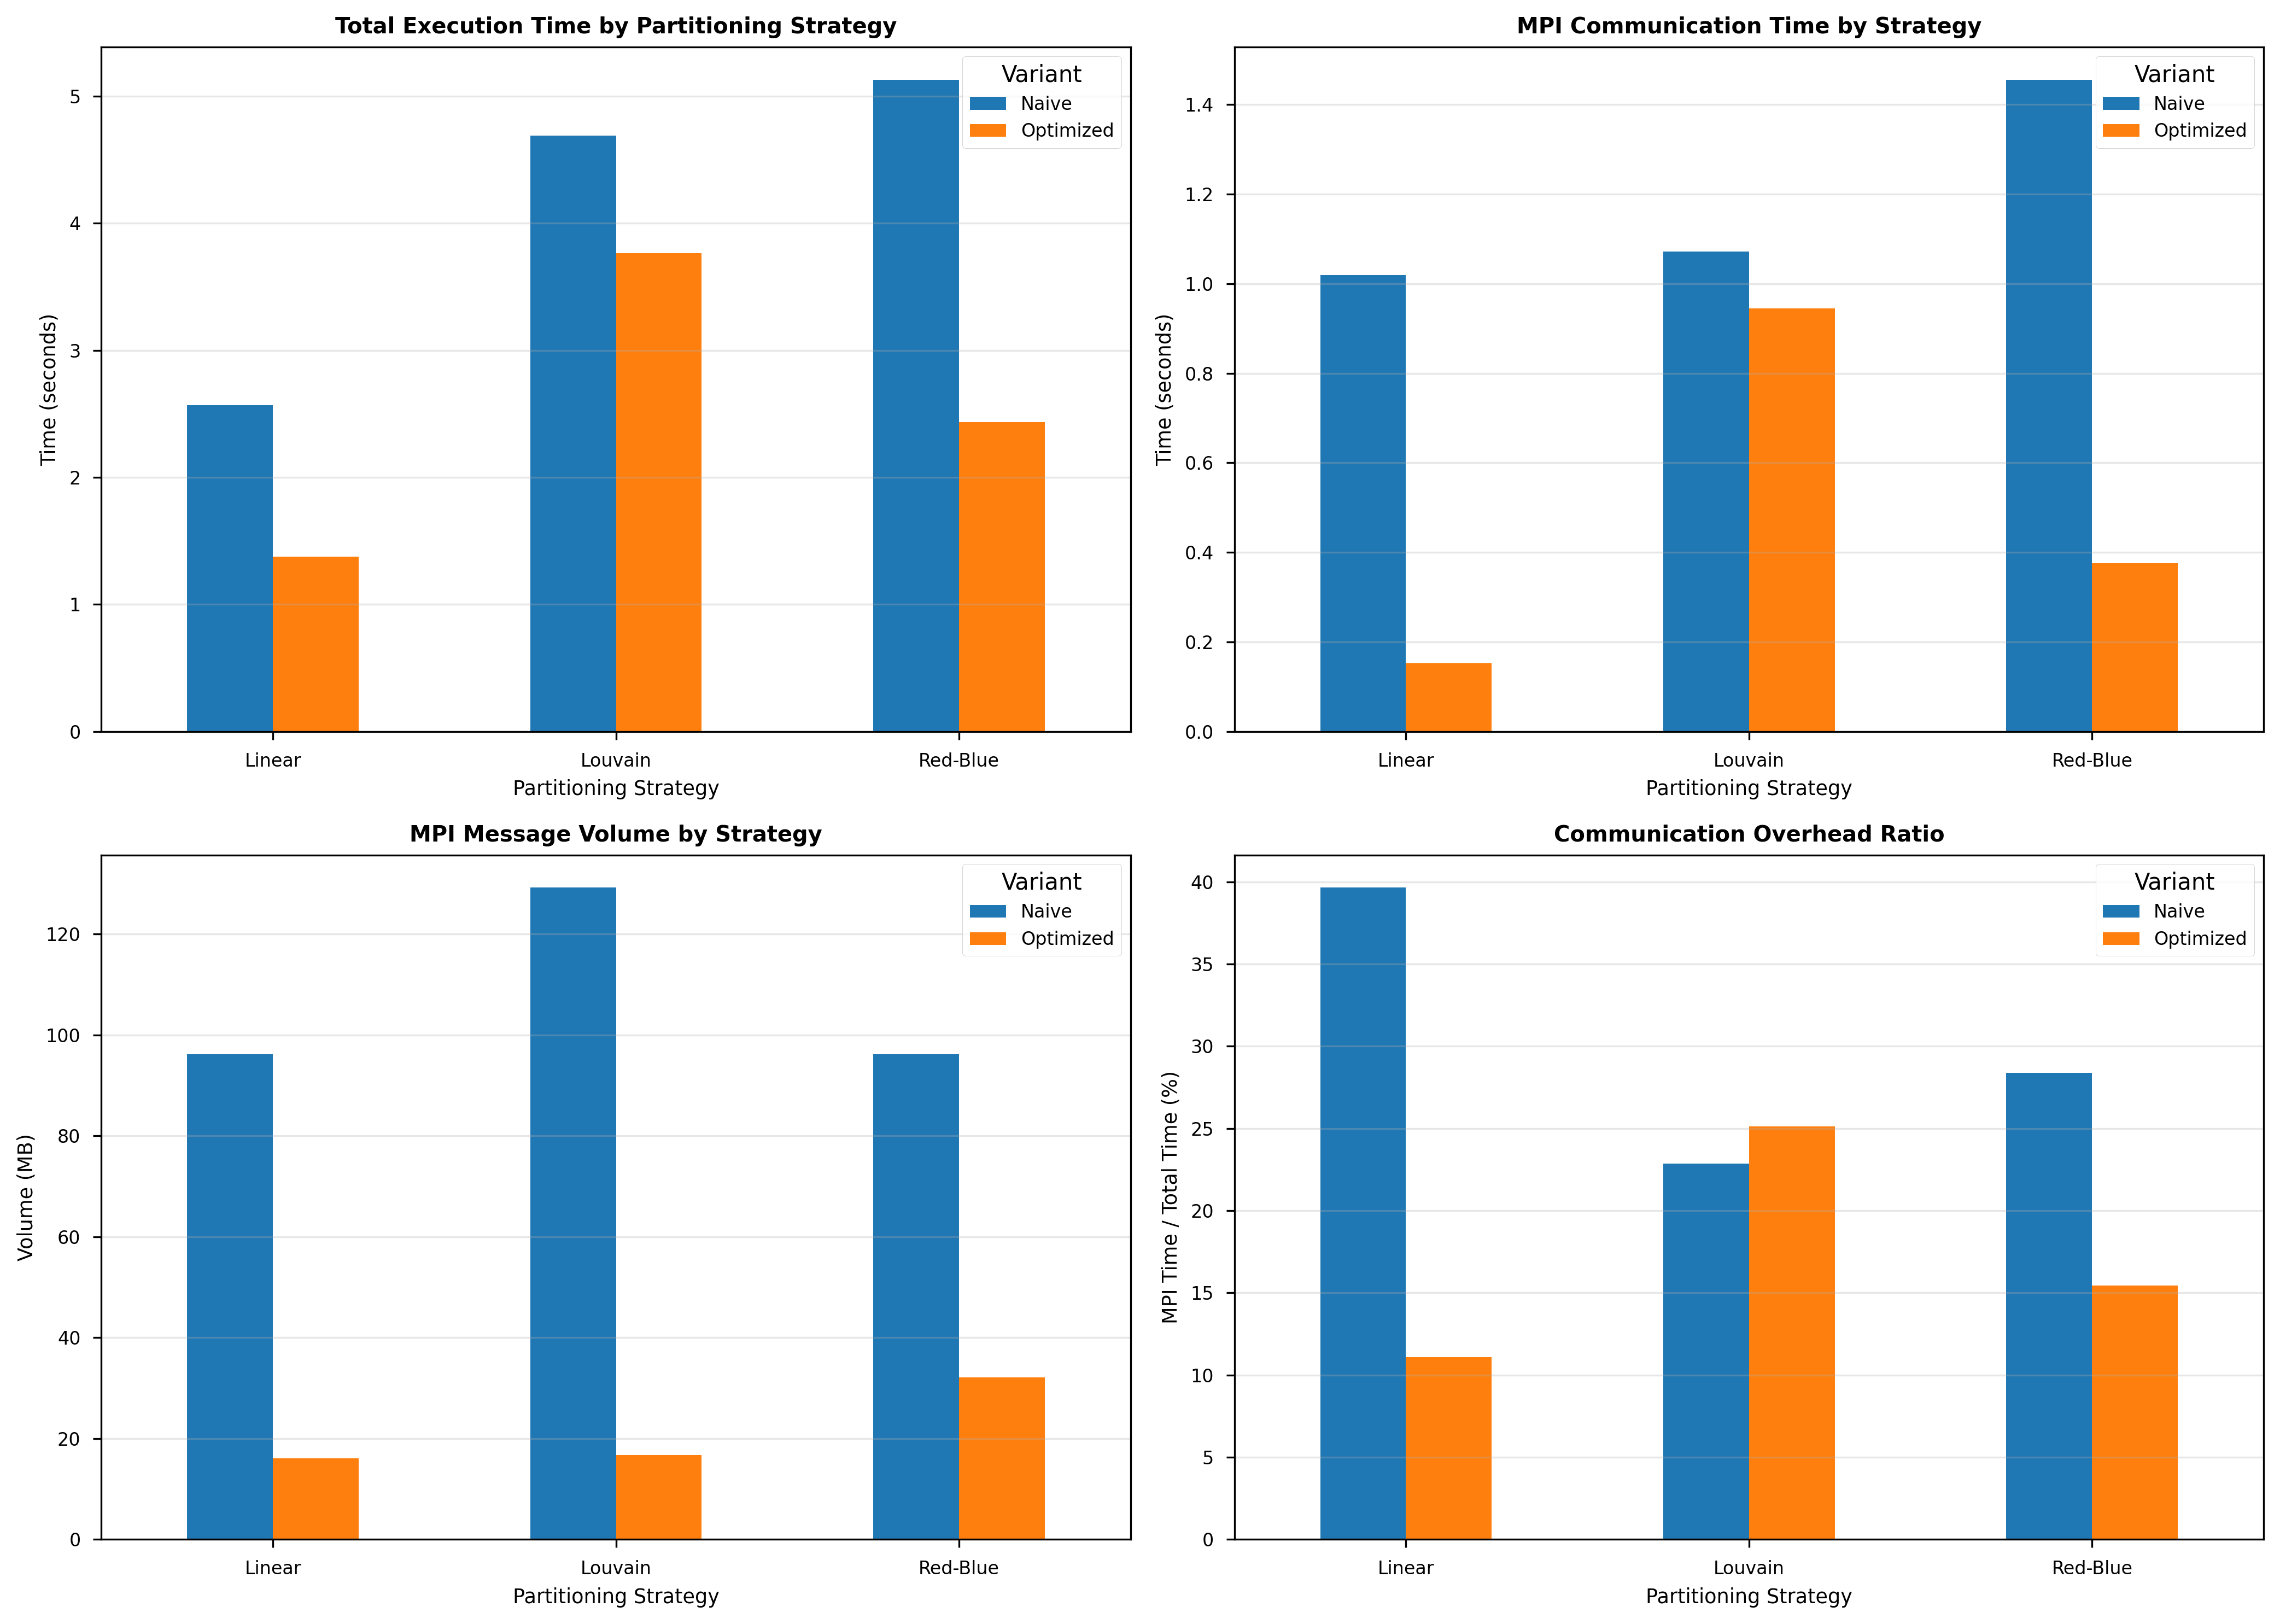


Partitioning Strategy Comparison:
strategy   variant  mpi_time_s  cuda_time_s  total_time_s  msg_volume_mb  comm_ratio
  Linear     Naive    1.018822     1.550310      2.569132      96.218750   39.656285
 Louvain     Naive    1.072283     3.618643      4.690926     129.232883   22.858673
Red-Blue     Naive    1.455482     3.674441      5.129923      96.218750   28.372399
  Linear Optimized    0.152367     1.222626      1.374993      16.062523   11.081324
 Louvain Optimized    0.944905     2.817497      3.762402      16.727695   25.114403
Red-Blue Optimized    0.375761     2.059457      2.435217      32.078148   15.430270


In [40]:
# Compare partitioning strategies
def extract_strategy(impl_name):
    """Extract partitioning strategy from implementation name."""
    if 'linear' in impl_name:
        return 'Linear'
    elif 'louvain' in impl_name:
        return 'Louvain'
    elif 'red-blue' in impl_name:
        return 'Red-Blue'
    return None

def extract_variant(impl_name):
    """Extract naive vs optimized variant."""
    return 'Naive' if 'naive' in impl_name else 'Optimized'

# Prepare comparison data
comparison_data = []
for impl in MPI_IMPLS:
    strategy = extract_strategy(impl)
    variant = extract_variant(impl)
    
    # Get MPI time
    mpi_df = load_csv_safely(impl, "stats_mpi_event_sum.csv")
    mpi_time = mpi_df['Total Time (ns)'].sum() / 1e9 if mpi_df is not None else 0
    
    # Get total CUDA time
    gpu_df = load_csv_safely(impl, "stats_cuda_api_gpu_sum.csv")
    cuda_time = gpu_df['Total Time (ns)'].sum() / 1e9 if gpu_df is not None else 0
    
    # Get message volume
    msg_df = load_csv_safely(impl, "stats_mpi_msg_size_sum.csv")
    msg_volume = msg_df['Total Message Volume'].sum() / (1024*1024) if msg_df is not None else 0
    
    comparison_data.append({
        'strategy': strategy,
        'variant': variant,
        'mpi_time_s': mpi_time,
        'cuda_time_s': cuda_time,
        'total_time_s': mpi_time + cuda_time,
        'msg_volume_mb': msg_volume,
        'comm_ratio': mpi_time / (mpi_time + cuda_time) * 100 if (mpi_time + cuda_time) > 0 else 0
    })

comp_df = pd.DataFrame(comparison_data)

if not comp_df.empty:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Plot 1: Total execution time by strategy
    ax = axes[0, 0]
    comp_pivot = comp_df.pivot(index='strategy', columns='variant', values='total_time_s')
    comp_pivot.plot(kind='bar', ax=ax, color=['#1f77b4', '#ff7f0e'])
    ax.set_title('Total Execution Time by Partitioning Strategy', fontweight='bold')
    ax.set_xlabel('Partitioning Strategy')
    ax.set_ylabel('Time (seconds)')
    ax.legend(title='Variant')
    ax.tick_params(axis='x', rotation=0)
    ax.grid(axis='y', alpha=0.3)
    
    # Plot 2: MPI communication time
    ax = axes[0, 1]
    comp_pivot = comp_df.pivot(index='strategy', columns='variant', values='mpi_time_s')
    comp_pivot.plot(kind='bar', ax=ax, color=['#1f77b4', '#ff7f0e'])
    ax.set_title('MPI Communication Time by Strategy', fontweight='bold')
    ax.set_xlabel('Partitioning Strategy')
    ax.set_ylabel('Time (seconds)')
    ax.legend(title='Variant')
    ax.tick_params(axis='x', rotation=0)
    ax.grid(axis='y', alpha=0.3)
    
    # Plot 3: Message volume
    ax = axes[1, 0]
    comp_pivot = comp_df.pivot(index='strategy', columns='variant', values='msg_volume_mb')
    comp_pivot.plot(kind='bar', ax=ax, color=['#1f77b4', '#ff7f0e'])
    ax.set_title('MPI Message Volume by Strategy', fontweight='bold')
    ax.set_xlabel('Partitioning Strategy')
    ax.set_ylabel('Volume (MB)')
    ax.legend(title='Variant')
    ax.tick_params(axis='x', rotation=0)
    ax.grid(axis='y', alpha=0.3)
    
    # Plot 4: Communication ratio (MPI time / total time)
    ax = axes[1, 1]
    comp_pivot = comp_df.pivot(index='strategy', columns='variant', values='comm_ratio')
    comp_pivot.plot(kind='bar', ax=ax, color=['#1f77b4', '#ff7f0e'])
    ax.set_title('Communication Overhead Ratio', fontweight='bold')
    ax.set_xlabel('Partitioning Strategy')
    ax.set_ylabel('MPI Time / Total Time (%)')
    ax.legend(title='Variant')
    ax.tick_params(axis='x', rotation=0)
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'partitioning_comparison.pdf', bbox_inches='tight')
    plt.savefig(OUTPUT_DIR / 'partitioning_comparison.png', bbox_inches='tight')
    plt.show()
    
    print("\nPartitioning Strategy Comparison:")
    print(comp_df.to_string(index=False))
else:
    print("No comparison data available.")

## Visualization 9: Overall Performance Comparison

**Purpose**: Speedup analysis showing relative performance of all implementations.

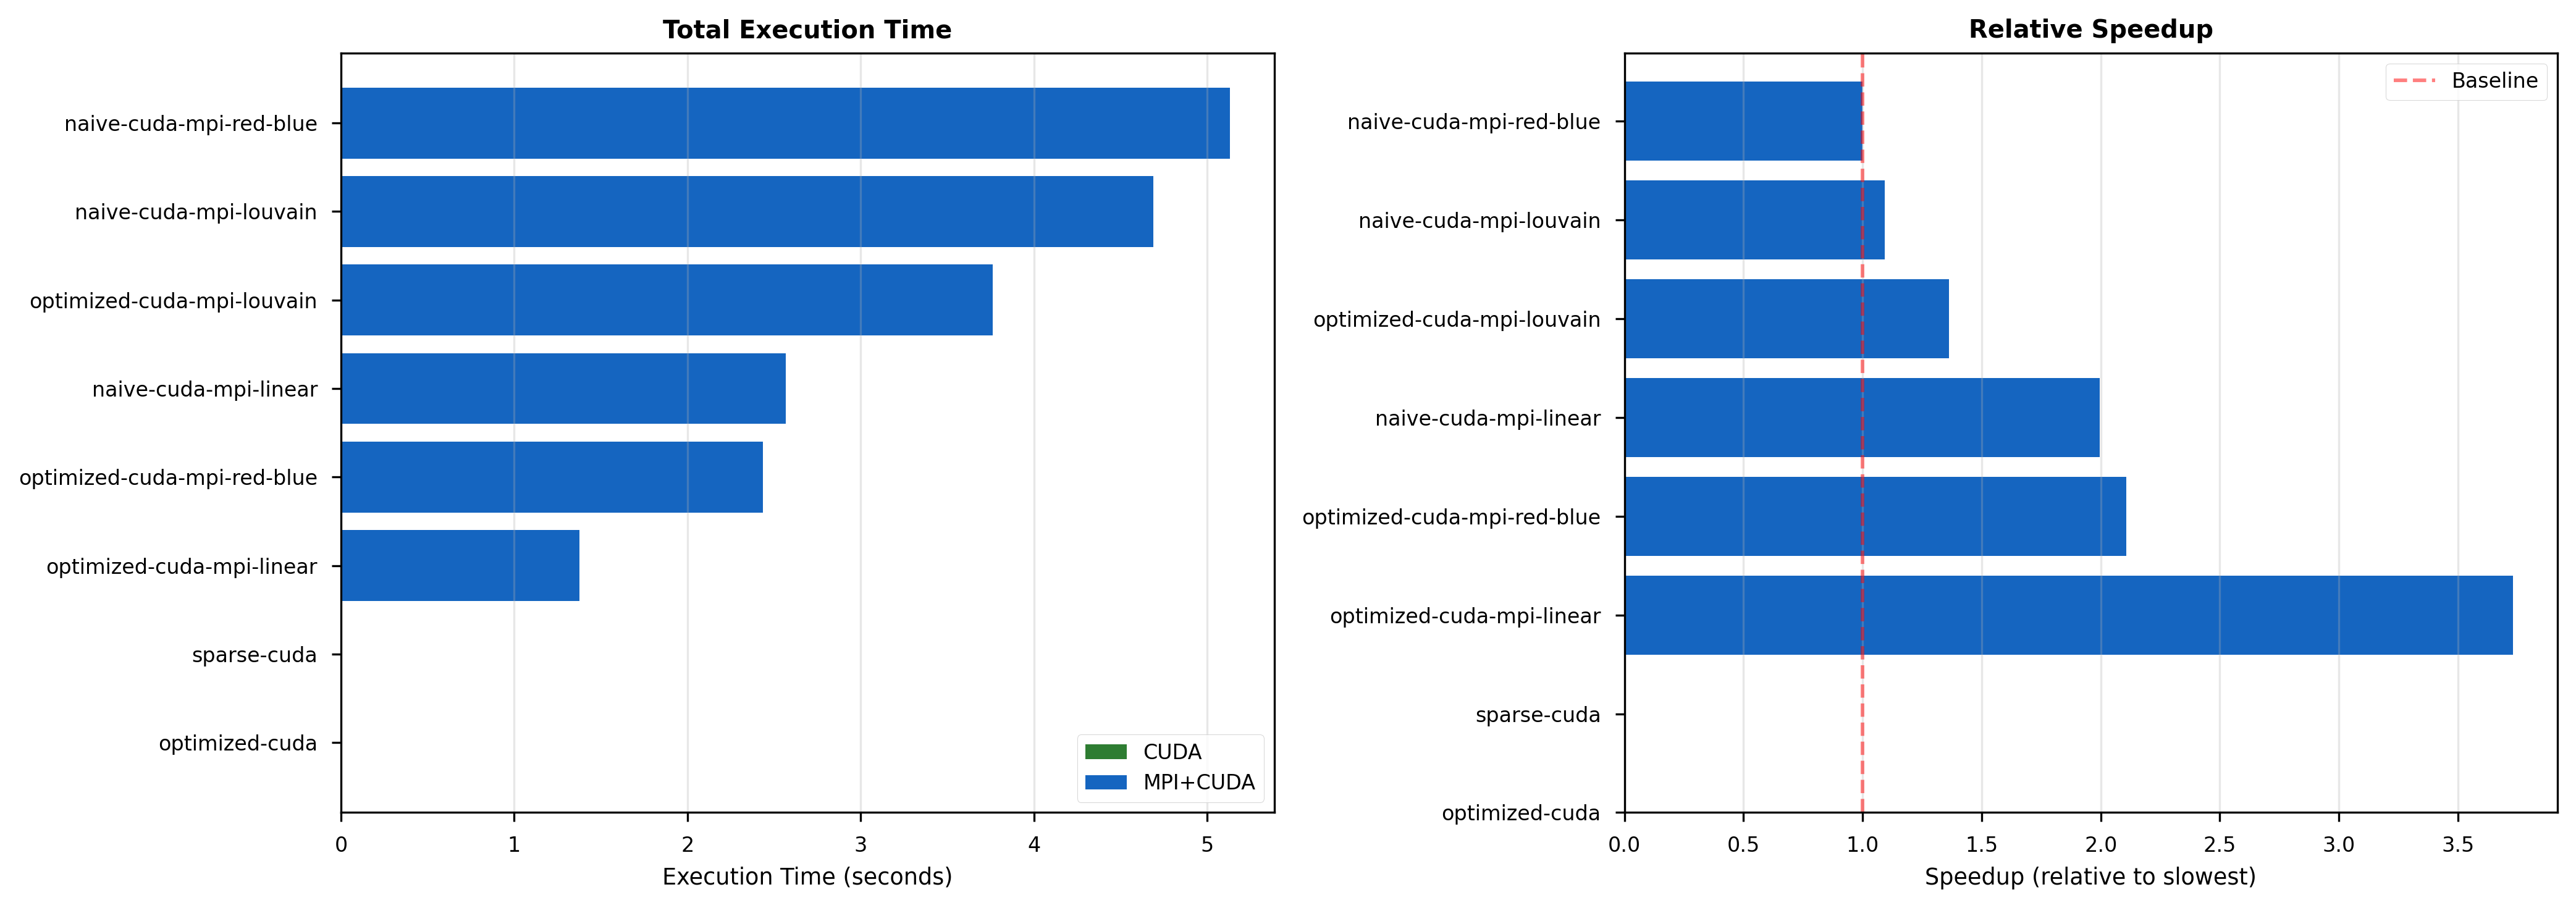


Overall Performance Summary:
             implementation  total_time_s  speedup
             optimized-cuda      0.000000      inf
                sparse-cuda      0.000000      inf
  optimized-cuda-mpi-linear      1.374993 3.730871
optimized-cuda-mpi-red-blue      2.435217 2.106557
      naive-cuda-mpi-linear      2.569132 1.996753
 optimized-cuda-mpi-louvain      3.762402 1.363470
     naive-cuda-mpi-louvain      4.690926 1.093584
    naive-cuda-mpi-red-blue      5.129923 1.000000


In [41]:
# Calculate total execution time for all implementations
perf_data = []
for impl in ALL_IMPLS:
    # Sum all major components
    gpu_df = load_csv_safely(impl, "stats_cuda_api_gpu_sum.csv")
    mpi_df = load_csv_safely(impl, "stats_mpi_event_sum.csv")
    
    cuda_time = gpu_df['Total Time (ns)'].sum() / 1e9 if gpu_df is not None else 0
    mpi_time = mpi_df['Total Time (ns)'].sum() / 1e9 if mpi_df is not None else 0
    total_time = cuda_time + mpi_time
    
    perf_data.append({
        'implementation': impl,
        'total_time_s': total_time,
        'type': 'CUDA' if impl in CUDA_IMPLS else 'MPI+CUDA'
    })

perf_df = pd.DataFrame(perf_data)
perf_df = perf_df.sort_values('total_time_s')

if not perf_df.empty and perf_df['total_time_s'].max() > 0:
    # Calculate speedup relative to slowest implementation
    baseline = perf_df['total_time_s'].max()
    perf_df['speedup'] = baseline / perf_df['total_time_s']
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot 1: Absolute execution time
    ax = axes[0]
    colors = ['#2E7D32' if t == 'CUDA' else '#1565C0' for t in perf_df['type']]
    bars = ax.barh(range(len(perf_df)), perf_df['total_time_s'], color=colors)
    ax.set_yticks(range(len(perf_df)))
    ax.set_yticklabels(perf_df['implementation'])
    ax.set_xlabel('Execution Time (seconds)')
    ax.set_title('Total Execution Time', fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    
    # Add legend
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor='#2E7D32', label='CUDA'),
                      Patch(facecolor='#1565C0', label='MPI+CUDA')]
    ax.legend(handles=legend_elements, loc='lower right')
    
    # Plot 2: Speedup
    ax = axes[1]
    bars = ax.barh(range(len(perf_df)), perf_df['speedup'], color=colors)
    ax.set_yticks(range(len(perf_df)))
    ax.set_yticklabels(perf_df['implementation'])
    ax.set_xlabel('Speedup (relative to slowest)')
    ax.set_title('Relative Speedup', fontweight='bold')
    ax.axvline(x=1, color='red', linestyle='--', alpha=0.5, label='Baseline')
    ax.grid(axis='x', alpha=0.3)
    ax.legend()
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'overall_performance.pdf', bbox_inches='tight')
    plt.savefig(OUTPUT_DIR / 'overall_performance.png', bbox_inches='tight')
    plt.show()
    
    print("\nOverall Performance Summary:")
    print(perf_df[['implementation', 'total_time_s', 'speedup']].to_string(index=False))
else:
    print("Insufficient performance data available.")

## Visualization 10: CUDA API Overhead Analysis

**Purpose**: Shows synchronization and launch overhead impact on performance.

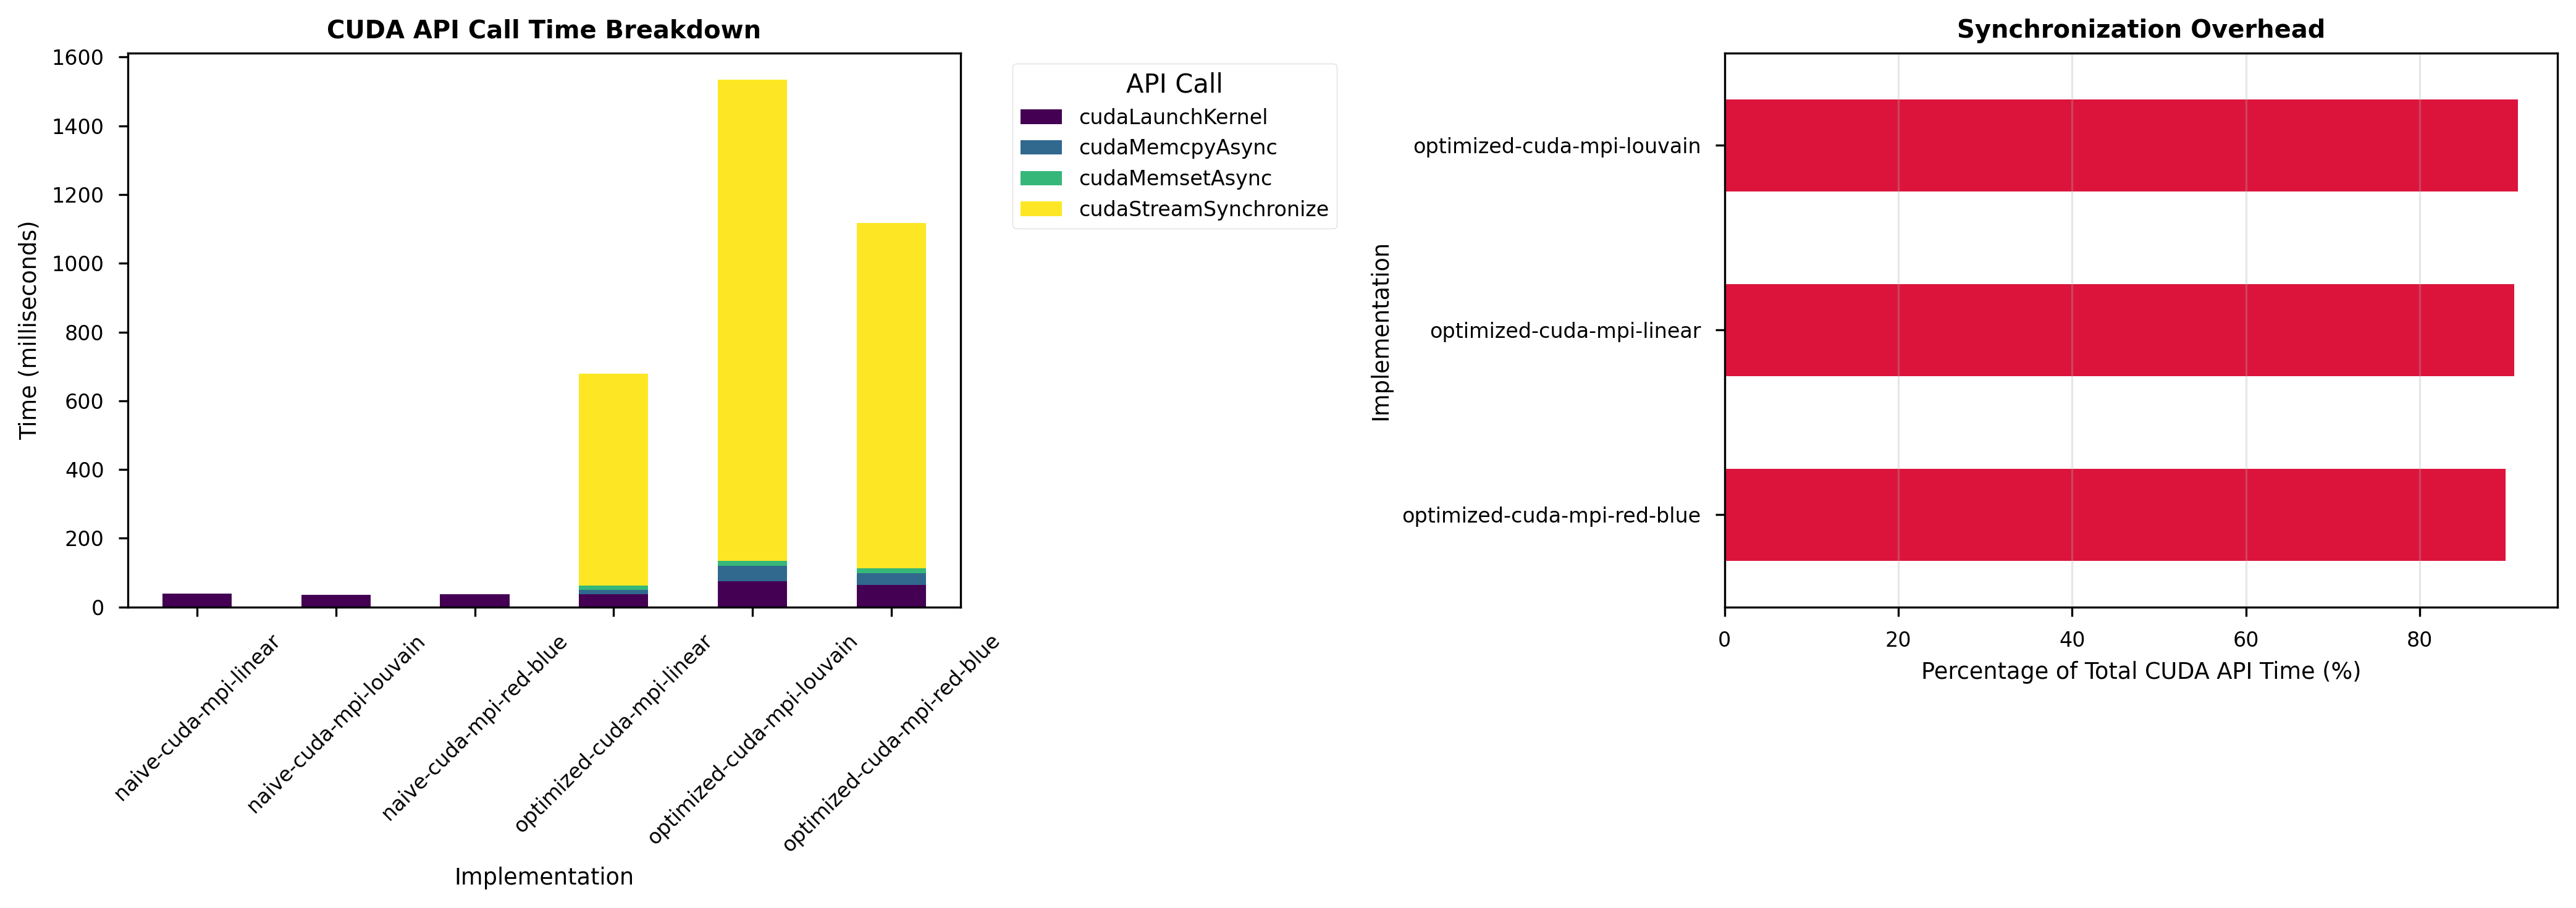


CUDA API Call Summary:

naive-cuda-mpi-linear:
             api_call    time_ms  num_calls
cudaDeviceSynchronize 766.959153       4100
           cudaMemcpy 115.114162       4101
     cudaLaunchKernel  38.254563       4100
      cuProfilerStart   0.008661          1

naive-cuda-mpi-louvain:
             api_call     time_ms  num_calls
           cudaMemcpy 1154.230157       4101
cudaDeviceSynchronize  738.753796       4100
     cudaLaunchKernel   35.783870       4100
      cuProfilerStart    0.008993          1

naive-cuda-mpi-red-blue:
             api_call     time_ms  num_calls
           cudaMemcpy 1165.127206       4101
cudaDeviceSynchronize  757.179406       4100
     cudaLaunchKernel   37.392497       4100
      cuProfilerStart    0.005081          1

optimized-cuda-mpi-linear:
             api_call    time_ms  num_calls
cudaStreamSynchronize 617.060603       6150
     cudaLaunchKernel  38.111888       6150
      cudaMemcpyAsync  12.625159       2050
      cudaMemsetAsync  11.1

In [42]:
# Analyze CUDA API overhead
cuda_api_data = load_all_implementations("stats_cuda_api_sum.csv")

api_breakdown = []
for impl, df in cuda_api_data.items():
    if df is not None and not df.empty:
        for _, row in df.iterrows():
            api_breakdown.append({
                'implementation': impl,
                'api_call': row['Name'],
                'time_ms': row['Total Time (ns)'] / 1e6,
                'percentage': row['Time (%)'],
                'num_calls': row['Num Calls']
            })

api_df = pd.DataFrame(api_breakdown)

if not api_df.empty:
    # Focus on major API calls
    major_apis = ['cudaStreamSynchronize', 'cudaLaunchKernel', 'cudaMemcpyAsync', 'cudaMemsetAsync']
    api_df_filtered = api_df[api_df['api_call'].isin(major_apis)]
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot 1: API call time breakdown
    ax = axes[0]
    pivot_api = api_df_filtered.pivot_table(index='implementation', columns='api_call',
                                            values='time_ms', fill_value=0)
    pivot_api.plot(kind='bar', stacked=True, ax=ax, colormap='viridis')
    ax.set_title('CUDA API Call Time Breakdown', fontweight='bold')
    ax.set_xlabel('Implementation')
    ax.set_ylabel('Time (milliseconds)')
    ax.legend(title='API Call', bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.tick_params(axis='x', rotation=45)
    
    # Plot 2: Synchronization overhead percentage
    ax = axes[1]
    sync_data = api_df[api_df['api_call'] == 'cudaStreamSynchronize']
    if not sync_data.empty:
        sync_pct = sync_data.set_index('implementation')['percentage'].sort_values()
        sync_pct.plot(kind='barh', ax=ax, color='crimson')
        ax.set_title('Synchronization Overhead', fontweight='bold')
        ax.set_xlabel('Percentage of Total CUDA API Time (%)')
        ax.set_ylabel('Implementation')
        ax.grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'cuda_api_overhead.pdf', bbox_inches='tight')
    plt.savefig(OUTPUT_DIR / 'cuda_api_overhead.png', bbox_inches='tight')
    plt.show()
    
    print("\nCUDA API Call Summary:")
    for impl in api_df['implementation'].unique():
        impl_data = api_df[api_df['implementation'] == impl]
        print(f"\n{impl}:")
        print(impl_data[['api_call', 'time_ms', 'num_calls']].to_string(index=False))
else:
    print("No CUDA API data available.")

## Summary Statistics Table

Generate a comprehensive table for inclusion in the paper.

In [43]:
# Create comprehensive summary table with CPU time from SQLite
print("Generating comprehensive summary table with CPU metrics...")
summary_rows = []

for impl in ALL_IMPLS:
    # Get detailed breakdown including CPU time from SQLite
    breakdown = get_detailed_time_breakdown(impl)
    
    if breakdown:
        cpu_time = breakdown.get('cpu_compute_s', 0)
        cuda_kernel_time = breakdown.get('cuda_kernel_s', 0)
        cuda_mem_time = breakdown.get('cuda_memory_s', 0)
        mpi_time = breakdown.get('mpi_s', 0)
        total_time = breakdown.get('total_execution_s', 0)
        
        # Message volume
        msg_df = load_csv_safely(impl, "stats_mpi_msg_size_sum.csv")
        msg_volume = msg_df['Total Message Volume'].sum() / (1024*1024) if msg_df is not None else 0
        
        # Calculate GPU utilization (kernel + memory / total)
        gpu_time = cuda_kernel_time + cuda_mem_time
        gpu_util = (gpu_time / total_time * 100) if total_time > 0 else 0
        cpu_ratio = (cpu_time / total_time * 100) if total_time > 0 else 0
        
        summary_rows.append({
            'Implementation': impl,
            'Total Time (s)': f"{total_time:.3f}",
            'CPU Time (s)': f"{cpu_time:.3f}",
            'CPU %': f"{cpu_ratio:.1f}",
            'CUDA Kernel (s)': f"{cuda_kernel_time:.3f}",
            'GPU Util %': f"{gpu_util:.1f}",
            'MPI Time (s)': f"{mpi_time:.3f}",
            'MPI Volume (MB)': f"{msg_volume:.2f}",
            'Comm. Ratio (%)': f"{(mpi_time/total_time*100):.1f}" if total_time > 0 else "N/A"
        })

summary_df = pd.DataFrame(summary_rows)
print("\n" + "="*100)
print("COMPREHENSIVE PERFORMANCE SUMMARY (with CPU Time)")
print("="*100)
print(summary_df.to_string(index=False))
print("="*100)

# Save to CSV for LaTeX table generation
summary_df.to_csv(OUTPUT_DIR / 'performance_summary_with_cpu.csv', index=False)
print(f"\nSummary table saved to: {OUTPUT_DIR / 'performance_summary_with_cpu.csv'}")

Generating comprehensive summary table with CPU metrics...
SQLite database not found for optimized-cuda rank 0
SQLite database not found for sparse-cuda rank 0

COMPREHENSIVE PERFORMANCE SUMMARY (with CPU Time)
             Implementation Total Time (s) CPU Time (s) CPU % CUDA Kernel (s) GPU Util % MPI Time (s) MPI Volume (MB) Comm. Ratio (%)
             optimized-cuda          0.000        0.000   0.0           0.000        0.0        0.000            0.00             N/A
                sparse-cuda          0.000        0.000   0.0           0.000        0.0        0.000            0.00             N/A
      naive-cuda-mpi-linear          2.008        0.360  17.9           0.617       31.4        1.019           96.22            50.7
     naive-cuda-mpi-louvain          3.127        0.364  11.7           1.675       54.0        1.072          129.23            34.3
    naive-cuda-mpi-red-blue          3.507        0.336   9.6           1.701       48.9        1.455           96.22  

## LaTeX Table Generation

Generate LaTeX code for direct inclusion in the paper.

In [44]:
# Generate LaTeX table
latex_table = summary_df.to_latex(index=False, 
                                   caption='Performance comparison of SNP system implementations',
                                   label='tab:performance',
                                   position='htbp',
                                   column_format='l' + 'r'*(len(summary_df.columns)-1))

# Save LaTeX table
with open(OUTPUT_DIR / 'performance_table.tex', 'w') as f:
    f.write(latex_table)

print("LaTeX Table for Paper:")
print("="*80)
print(latex_table)
print("="*80)
print(f"\nLaTeX table saved to: {OUTPUT_DIR / 'performance_table.tex'}")

LaTeX Table for Paper:
\begin{table}[htbp]
\caption{Performance comparison of SNP system implementations}
\label{tab:performance}
\begin{tabular}{lrrrrrrrr}
\toprule
Implementation & Total Time (s) & CPU Time (s) & CPU % & CUDA Kernel (s) & GPU Util % & MPI Time (s) & MPI Volume (MB) & Comm. Ratio (%) \\
\midrule
optimized-cuda & 0.000 & 0.000 & 0.0 & 0.000 & 0.0 & 0.000 & 0.00 & N/A \\
sparse-cuda & 0.000 & 0.000 & 0.0 & 0.000 & 0.0 & 0.000 & 0.00 & N/A \\
naive-cuda-mpi-linear & 2.008 & 0.360 & 17.9 & 0.617 & 31.4 & 1.019 & 96.22 & 50.7 \\
naive-cuda-mpi-louvain & 3.127 & 0.364 & 11.7 & 1.675 & 54.0 & 1.072 & 129.23 & 34.3 \\
naive-cuda-mpi-red-blue & 3.507 & 0.336 & 9.6 & 1.701 & 48.9 & 1.455 & 96.22 & 41.5 \\
optimized-cuda-mpi-linear & 0.935 & 0.239 & 25.6 & 0.532 & 58.1 & 0.152 & 16.06 & 16.3 \\
optimized-cuda-mpi-louvain & 2.641 & 0.413 & 15.6 & 1.262 & 48.6 & 0.945 & 16.73 & 35.8 \\
optimized-cuda-mpi-red-blue & 1.630 & 0.313 & 19.2 & 0.923 & 57.8 & 0.376 & 32.08 & 23.1 \\
\bot

## Analysis Complete

All visualizations have been generated and saved to the output directory. Files include:
- PDF and PNG versions of all plots (for paper submission)
- CSV summary data
- LaTeX table code

### Key Findings to Highlight in Paper:

1. **GPU Acceleration Effectiveness**: Quantify how much time is spent in CUDA kernels vs overhead
2. **MPI Communication Impact**: Show communication overhead ratio for distributed implementations
3. **Partitioning Strategy Benefits**: Compare linear vs graph-based partitioning effectiveness
4. **Optimization Impact**: Demonstrate naive vs optimized implementation improvements
5. **Scalability Bottlenecks**: Identify whether communication or computation limits performance